# Composition and sequence models for GCN4 speed and strength

This notebook compares a small set of regression models for predicting **speed** and **strength** from the GCN4 activation domain sequence. The requested baselines are included explicitly:

- **linear regression on amino-acid composition**
- **linear regression on one-hot encoded sequence identity**

To see whether less interpretable models help, the notebook also benchmarks a few additional regressors on the same train/test split and 5-fold cross-validation.


In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from scipy.stats import pearsonr
from IPython.display import display

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNetCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_context('talk')
sns.set_style('white')
RANDOM_STATE = 42
AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')


## Load the fitted speed and strength values


In [193]:
exponential_fit = pd.read_csv('../../../output/GCN4_pipeline/speed/exponential_fit.csv', index_col=0)
exponential_fit = exponential_fit[['ADseq', 'A+C', 'k']].rename(
    columns={'A+C': 'strength', 'k': 'speed'}
)

exponential_fit.head()

/global/home/users/sanjanakotha/.local/lib/python3.11/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


,ADseq,strength,speed
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.986402,0.074620
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.129853,0.146610
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.706721,0.159460
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,3.630930,0.155566
5,AAEDSSKCPSTKAGTTEPDALFNWALDVACGADPIQQWTF,3.971689,0.155898


,mean,std,min,max,n_sequences
speed,0.136850,0.048751,0.025054,0.336329,1557
strength,2.839458,1.184237,0.146219,5.855390,1557


/global/home/users/sanjanakotha/.local/lib/python3.11/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/global/home/users/sanjanakotha/.local/lib/python3.11/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


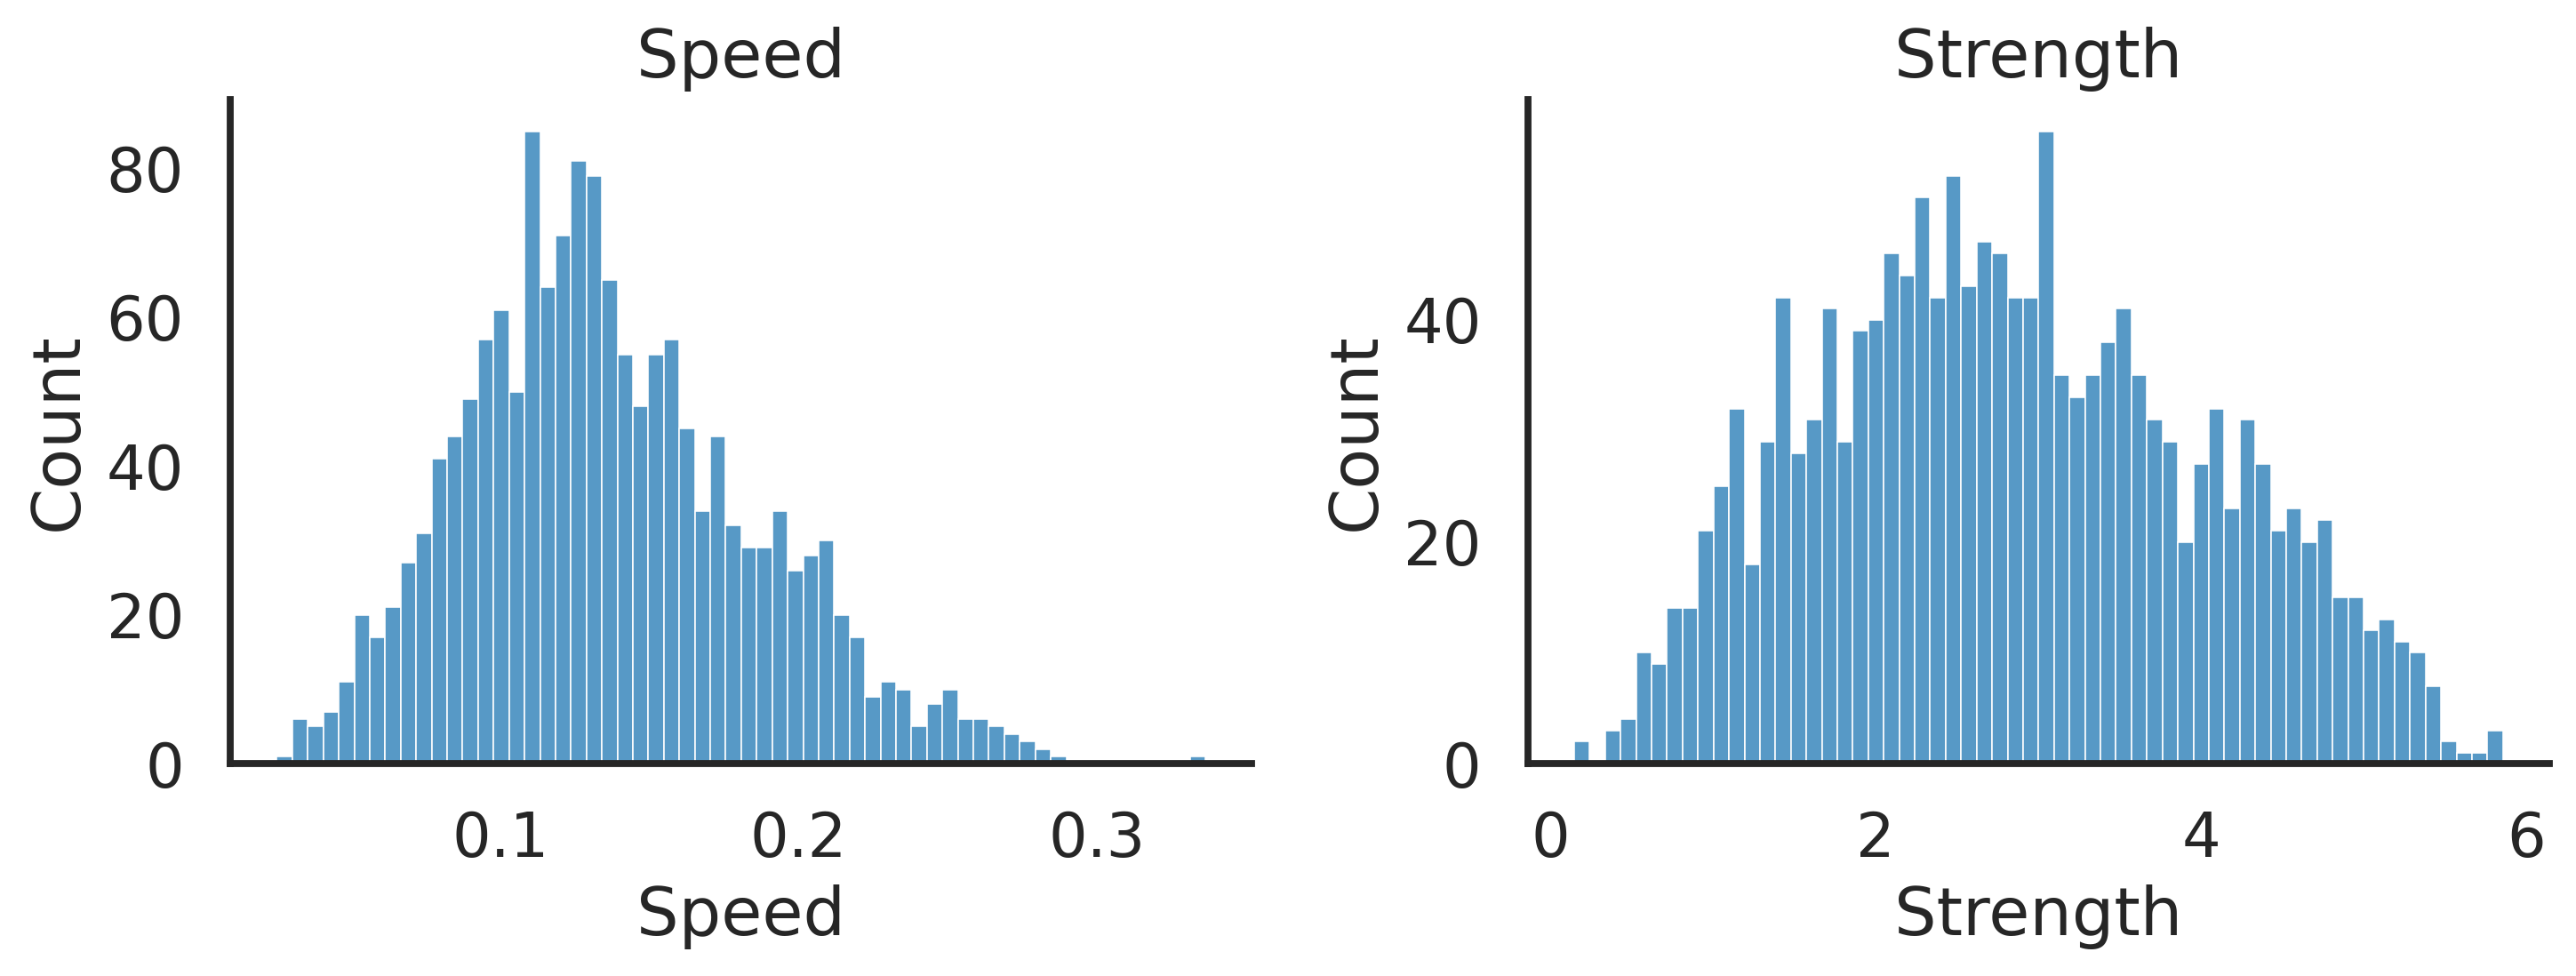

In [194]:
summary_df = exponential_fit[['speed', 'strength']].agg(['mean', 'std', 'min', 'max']).T
summary_df['n_sequences'] = len(exponential_fit)
display(summary_df)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=300)
for ax, column in zip(axs, ['speed', 'strength']):
    sns.histplot(exponential_fit[column], bins=60, ax=ax)
    ax.set_title(column.capitalize())
    ax.set_xlabel(column.capitalize())
    ax.set_ylabel('Count')

sns.despine()
plt.tight_layout()

## Shared feature engineering and evaluation helpers


In [195]:
def aa_composition(seq):
    counts = Counter(seq)
    length = len(seq)
    return {aa: counts.get(aa, 0) / length for aa in AMINO_ACIDS}


def build_one_hot_features(seqs):
    seq_lengths = pd.Series(seqs).str.len()
    assert seq_lengths.nunique() == 1, 'Sequences must all have the same length'
    seq_length = int(seq_lengths.iloc[0])

    aa_to_idx = {aa: idx for idx, aa in enumerate(AMINO_ACIDS)}
    feature_names = [
        f'pos{pos + 1:02d}_{aa}'
        for pos in range(seq_length)
        for aa in AMINO_ACIDS
    ]

    encoded = np.zeros((len(seqs), seq_length * len(AMINO_ACIDS)), dtype=np.float32)
    for row_idx, seq in enumerate(seqs):
        for pos, aa in enumerate(seq):
            if aa not in aa_to_idx:
                raise ValueError(f'Unexpected amino acid {aa!r} in sequence {seq!r}')
            encoded[row_idx, pos * len(AMINO_ACIDS) + aa_to_idx[aa]] = 1.0

    return pd.DataFrame(encoded, columns=feature_names), seq_length


def safe_pearson(y_true, y_pred):
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return pearsonr(y_true, y_pred)[0]


def metric_row(y_true, y_pred, feature_set, target_name, model_name, split_name):
    return {
        'feature_set': feature_set,
        'target': target_name,
        'model': model_name,
        'split': split_name,
        'r2': r2_score(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'pearson_r': safe_pearson(y_true, y_pred),
    }


def evaluate_model(builder, X, y, feature_set, target_name, train_idx, test_idx, cv):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    estimator = builder()
    estimator.fit(X_train, y_train)
    y_test_pred = estimator.predict(X_test)

    cv_estimator = builder()
    y_cv_pred = cross_val_predict(cv_estimator, X, y, cv=cv)

    summary_rows = [
        metric_row(y_test, y_test_pred, feature_set, target_name, estimator.__class__.__name__, 'holdout'),
        metric_row(y, y_cv_pred, feature_set, target_name, estimator.__class__.__name__, '5-fold CV'),
    ]

    return summary_rows, {
        'estimator': estimator,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'y_cv_pred': y_cv_pred,
    }


def benchmark_models(X, targets, model_builders, feature_set, train_idx, test_idx, cv):
    rows = []
    artifacts = {}
    for target_name, y in targets.items():
        for model_name, builder in model_builders.items():
            summary_rows, artifact = evaluate_model(
                builder, X, y, feature_set, target_name, train_idx, test_idx, cv
            )
            for row in summary_rows:
                row['model'] = model_name
            rows.extend(summary_rows)
            artifacts[(feature_set, target_name, model_name)] = artifact
    return pd.DataFrame(rows), artifacts


def coefficient_table(model, feature_names, n=12):
    coef = np.asarray(model.coef_).reshape(-1)
    coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
    coef_df['abs_coef'] = coef_df['coef'].abs()
    return coef_df.sort_values('abs_coef', ascending=False).head(n)


def plot_prediction_grid(artifacts, feature_set, model_name, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300, sharex=False, sharey=False)
    for ax, target_name in zip(axes, ['speed', 'strength']):
        artifact = artifacts[(feature_set, target_name, model_name)]
        y_true = artifact['y_test']
        y_pred = artifact['y_test_pred']
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='none')
        ax.plot(lims, lims, 'r--', lw=1)
        ax.set_title(
            f"{target_name.capitalize()}\nR²={r2_score(y_true, y_pred):.2f}, r={safe_pearson(y_true, y_pred):.2f}"
        )
        ax.set_xlabel('Observed')
        ax.set_ylabel('Predicted')
    fig.suptitle(f'GCN4 {title_prefix}: {model_name}', y=0.95)
    sns.despine()
    plt.tight_layout()


## Build the composition and one-hot feature sets


In [196]:
composition_df = pd.DataFrame(exponential_fit['ADseq'].apply(aa_composition).tolist())
onehot_df, seq_length = build_one_hot_features(exponential_fit['ADseq'])

targets = {
    'speed': exponential_fit['speed'].to_numpy(),
    'strength': exponential_fit['strength'].to_numpy(),
}

train_idx, test_idx = train_test_split(
    np.arange(len(exponential_fit)), test_size=0.2, random_state=RANDOM_STATE
)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pd.DataFrame({
    'feature_set': ['composition', 'one_hot_sequence'],
    'n_samples': [len(composition_df), len(onehot_df)],
    'n_features': [composition_df.shape[1], onehot_df.shape[1]],
    'sequence_length': [seq_length, seq_length],
})


,feature_set,n_samples,n_features,sequence_length
0,composition,1557,20,40
1,one_hot_sequence,1557,800,40


## Linear and ridge-regression baselines

This section benchmarks ordinary least-squares (**Linear regression**) and **Ridge regression** on both feature spaces:
- amino-acid **composition**
- **one-hot encoded sequence**


In [205]:
linear_models = {'Linear regression': lambda: LinearRegression()}
ridge_alphas = np.logspace(-4, 4, 81)
ridge_models = {'Ridge regression': lambda: RidgeCV(alphas=ridge_alphas)}

composition_linear_summary, composition_linear_artifacts = benchmark_models(
    composition_df, targets, linear_models, 'composition', train_idx, test_idx, cv
)
onehot_linear_summary, onehot_linear_artifacts = benchmark_models(
    onehot_df, targets, linear_models, 'one_hot_sequence', train_idx, test_idx, cv
)

composition_ridge_summary, composition_ridge_artifacts = benchmark_models(
    composition_df, targets, ridge_models, 'composition', train_idx, test_idx, cv
)
onehot_ridge_summary, onehot_ridge_artifacts = benchmark_models(
    onehot_df, targets, ridge_models, 'one_hot_sequence', train_idx, test_idx, cv
)

model_summary = (
    pd.concat(
        [
            composition_linear_summary,
            onehot_linear_summary,
            composition_ridge_summary,
            onehot_ridge_summary,
        ],
        ignore_index=True,
    )
    .sort_values(['split', 'target', 'model', 'r2'], ascending=[True, True, True, False])
    .reset_index(drop=True)
)

display(model_summary)

ridge_alpha_rows = []
for feature_set, artifacts in [
    ('composition', composition_ridge_artifacts),
    ('one_hot_sequence', onehot_ridge_artifacts),
]:
    for target_name in ['speed', 'strength']:
        ridge_alpha_rows.append(
            {
                'feature_set': feature_set,
                'target': target_name,
                'selected_alpha': artifacts[(feature_set, target_name, 'Ridge regression')]['estimator'].alpha_,
            }
        )

display(pd.DataFrame(ridge_alpha_rows))


,feature_set,target,model,split,r2,rmse,pearson_r
0,composition,speed,Linear regression,5-fold CV,0.307844,0.040546,0.555193
1,one_hot_sequence,speed,Linear regression,5-fold CV,-0.712286,0.063772,0.297975
2,composition,speed,Ridge regression,5-fold CV,0.307955,0.040543,0.555046
3,one_hot_sequence,speed,Ridge regression,5-fold CV,0.178840,0.044163,0.423735
4,composition,strength,Linear regression,5-fold CV,0.582526,0.764916,0.763326
5,one_hot_sequence,strength,Linear regression,5-fold CV,0.156858,1.087049,0.628041
6,composition,strength,Ridge regression,5-fold CV,0.582638,0.764813,0.763322
7,one_hot_sequence,strength,Ridge regression,5-fold CV,0.412898,0.907101,0.645447
8,composition,speed,Linear regression,holdout,0.241149,0.042315,0.502966
9,one_hot_sequence,speed,Linear regression,holdout,-0.468309,0.058860,0.345173


,feature_set,target,selected_alpha
0,composition,speed,0.012589
1,composition,strength,0.006310
2,one_hot_sequence,speed,63.095734
3,one_hot_sequence,strength,19.952623


Top composition coefficients for speed (Linear regression)


,feature,coef,abs_coef
18,W,0.666594,0.666594
1,C,-0.579626,0.579626
4,F,0.440198,0.440198
14,R,-0.383795,0.383795
2,D,0.283516,0.283516
10,M,0.254458,0.254458
8,K,-0.153464,0.153464
5,G,-0.102596,0.102596
17,V,-0.093819,0.093819
6,H,-0.090647,0.090647


Top composition coefficients for strength (Linear regression)


,feature,coef,abs_coef
18,W,23.979941,23.979941
14,R,-14.715285,14.715285
4,F,14.040271,14.040271
8,K,-12.453091,12.453091
10,M,9.632442,9.632442
9,L,7.394283,7.394283
6,H,-7.245927,7.245927
13,Q,-6.629784,6.629784
5,G,-5.852772,5.852772
7,I,5.470350,5.470350


Top one_hot_sequence coefficients for speed (Linear regression)


...

,feature,coef,abs_coef
18,W,22.906958,22.906958
14,R,-14.514462,14.514462
4,F,13.840847,13.840847
8,K,-12.091794,12.091794
10,M,9.390661,9.390661
9,L,7.292526,7.292526
6,H,-7.137865,7.137865
13,Q,-6.495838,6.495838
5,G,-5.696248,5.696248
7,I,5.335028,5.335028


Top one_hot_sequence coefficients for speed (Ridge regression)


,feature,coef,abs_coef
282,pos15_D,0.009308,0.009308
284,pos15_F,0.009279,0.009279
242,pos13_D,0.008662,0.008662
84,pos05_F,0.008414,0.008414
482,pos25_D,0.008348,0.008348
442,pos23_D,0.008228,0.008228
122,pos07_D,0.008086,0.008086
144,pos08_F,0.008042,0.008042
234,pos12_R,-0.008035,0.008035
182,pos10_D,0.007933,0.007933


Top one_hot_sequence coefficients for strength (Ridge regression)


,feature,coef,abs_coef
374,pos19_R,-0.326675,0.326675
578,pos29_W,0.326481,0.326481
216,pos11_T,-0.318161,0.318161
242,pos13_D,0.298412,0.298412
174,pos09_R,-0.293040,0.293040
744,pos38_F,0.288913,0.288913
204,pos11_F,0.286957,0.286957
284,pos15_F,0.284470,0.284470
322,pos17_D,0.281648,0.281648
622,pos32_D,0.274459,0.274459


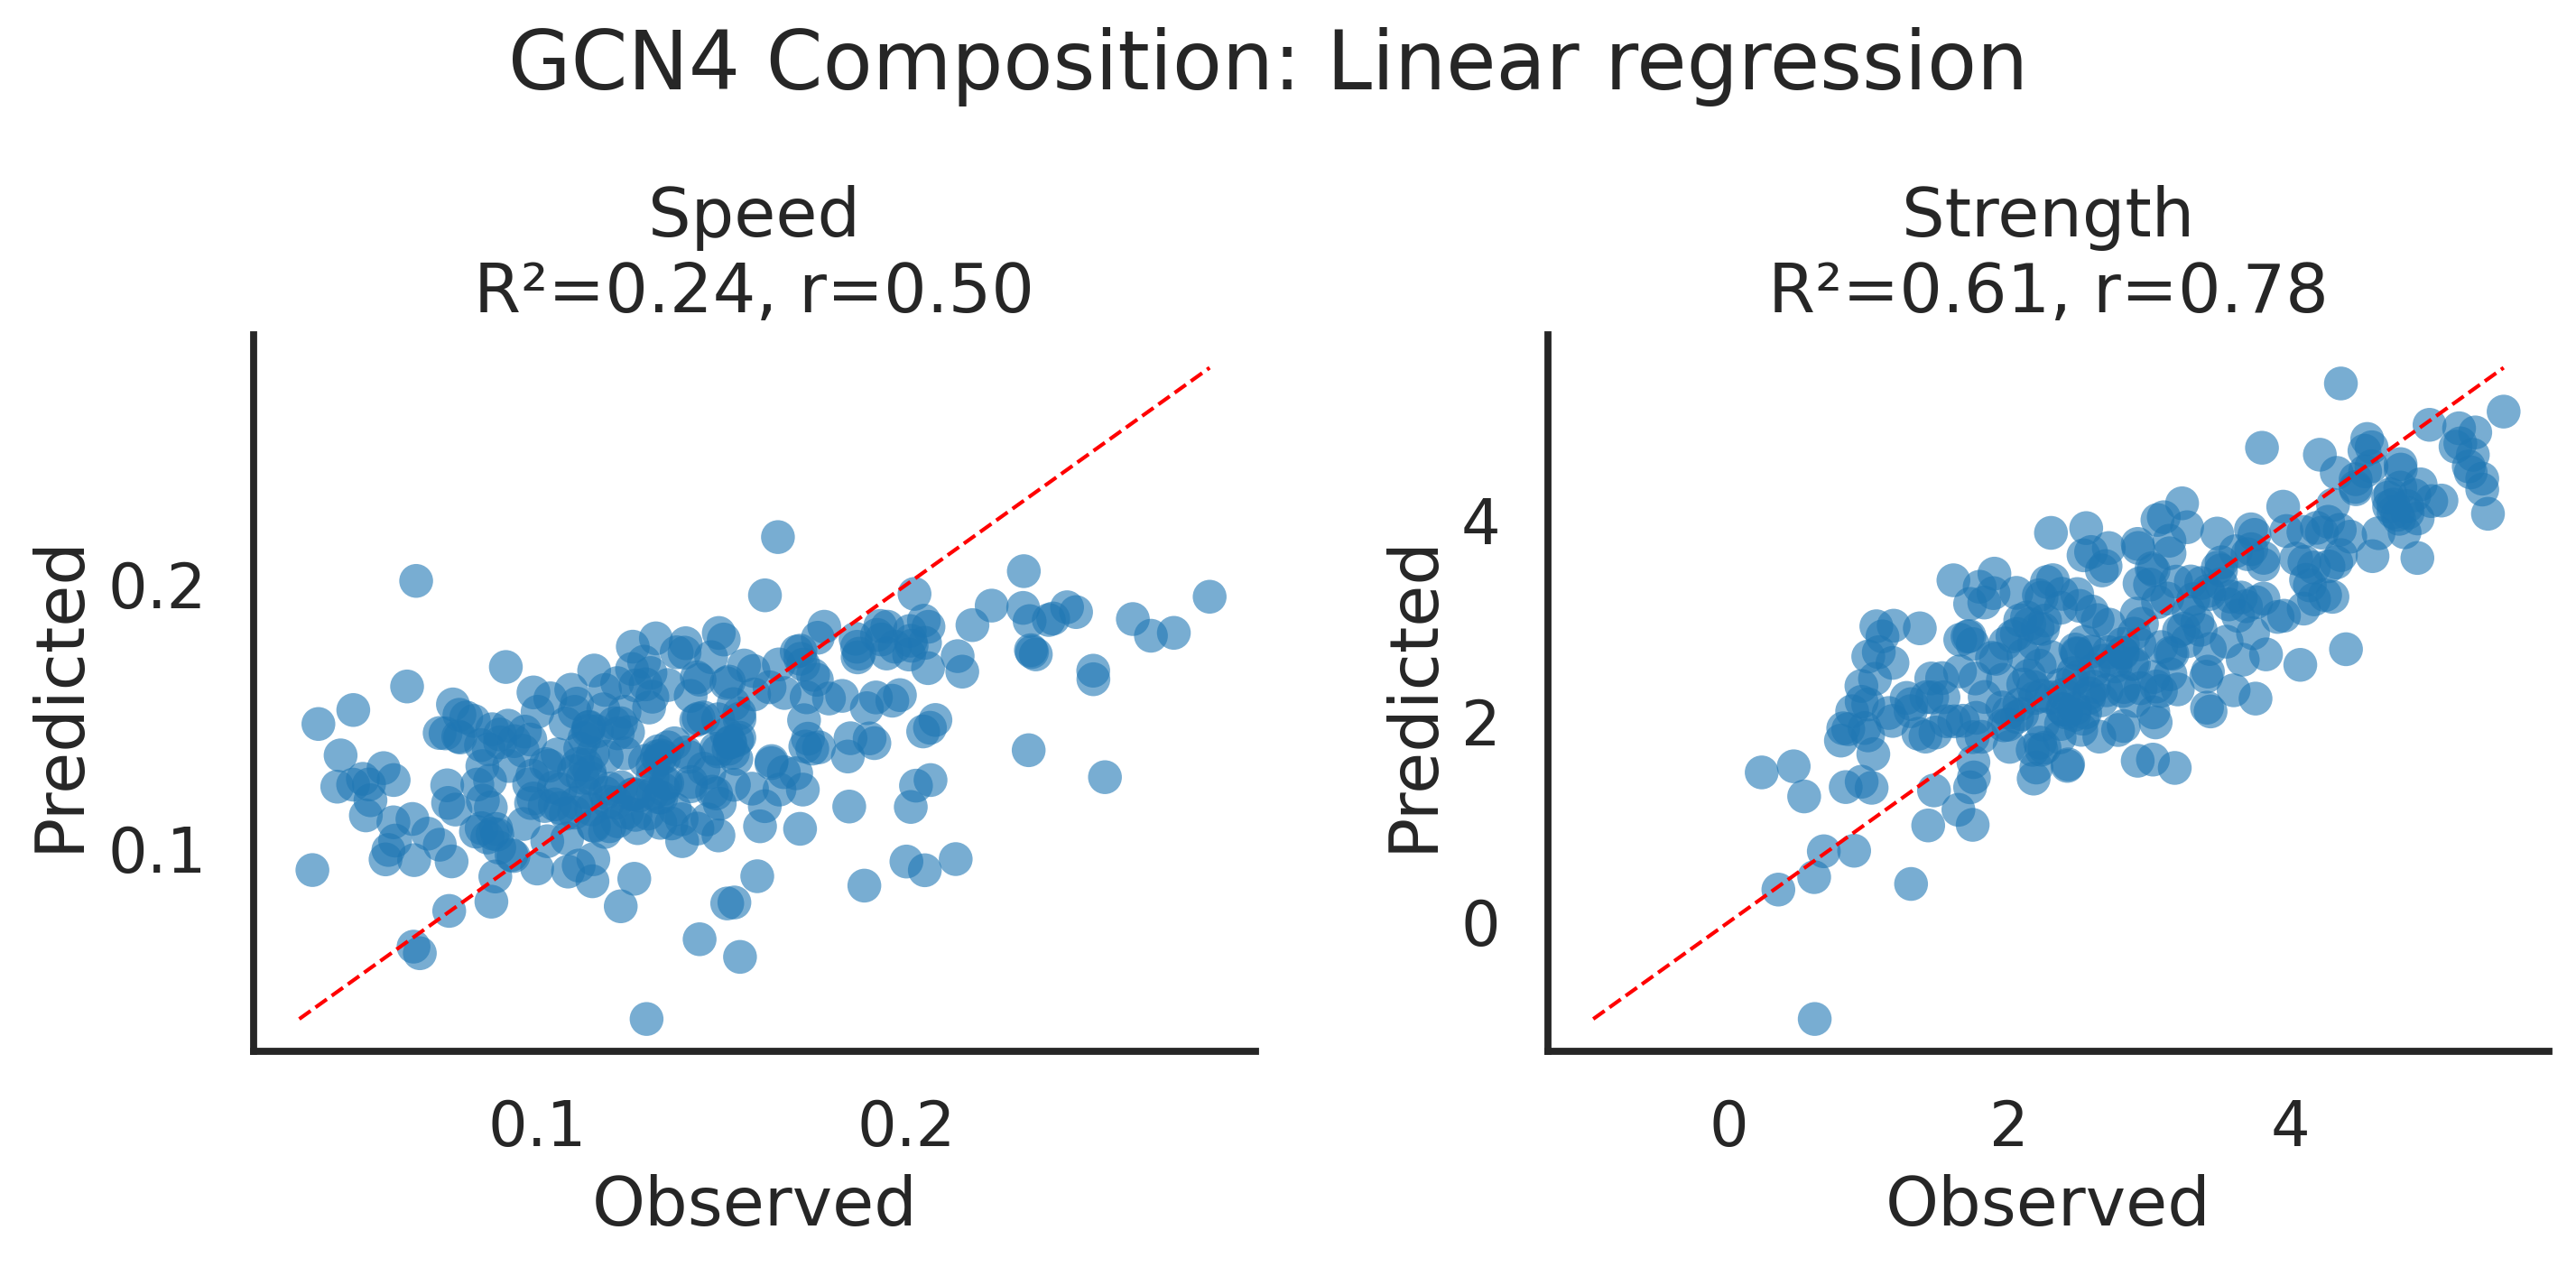

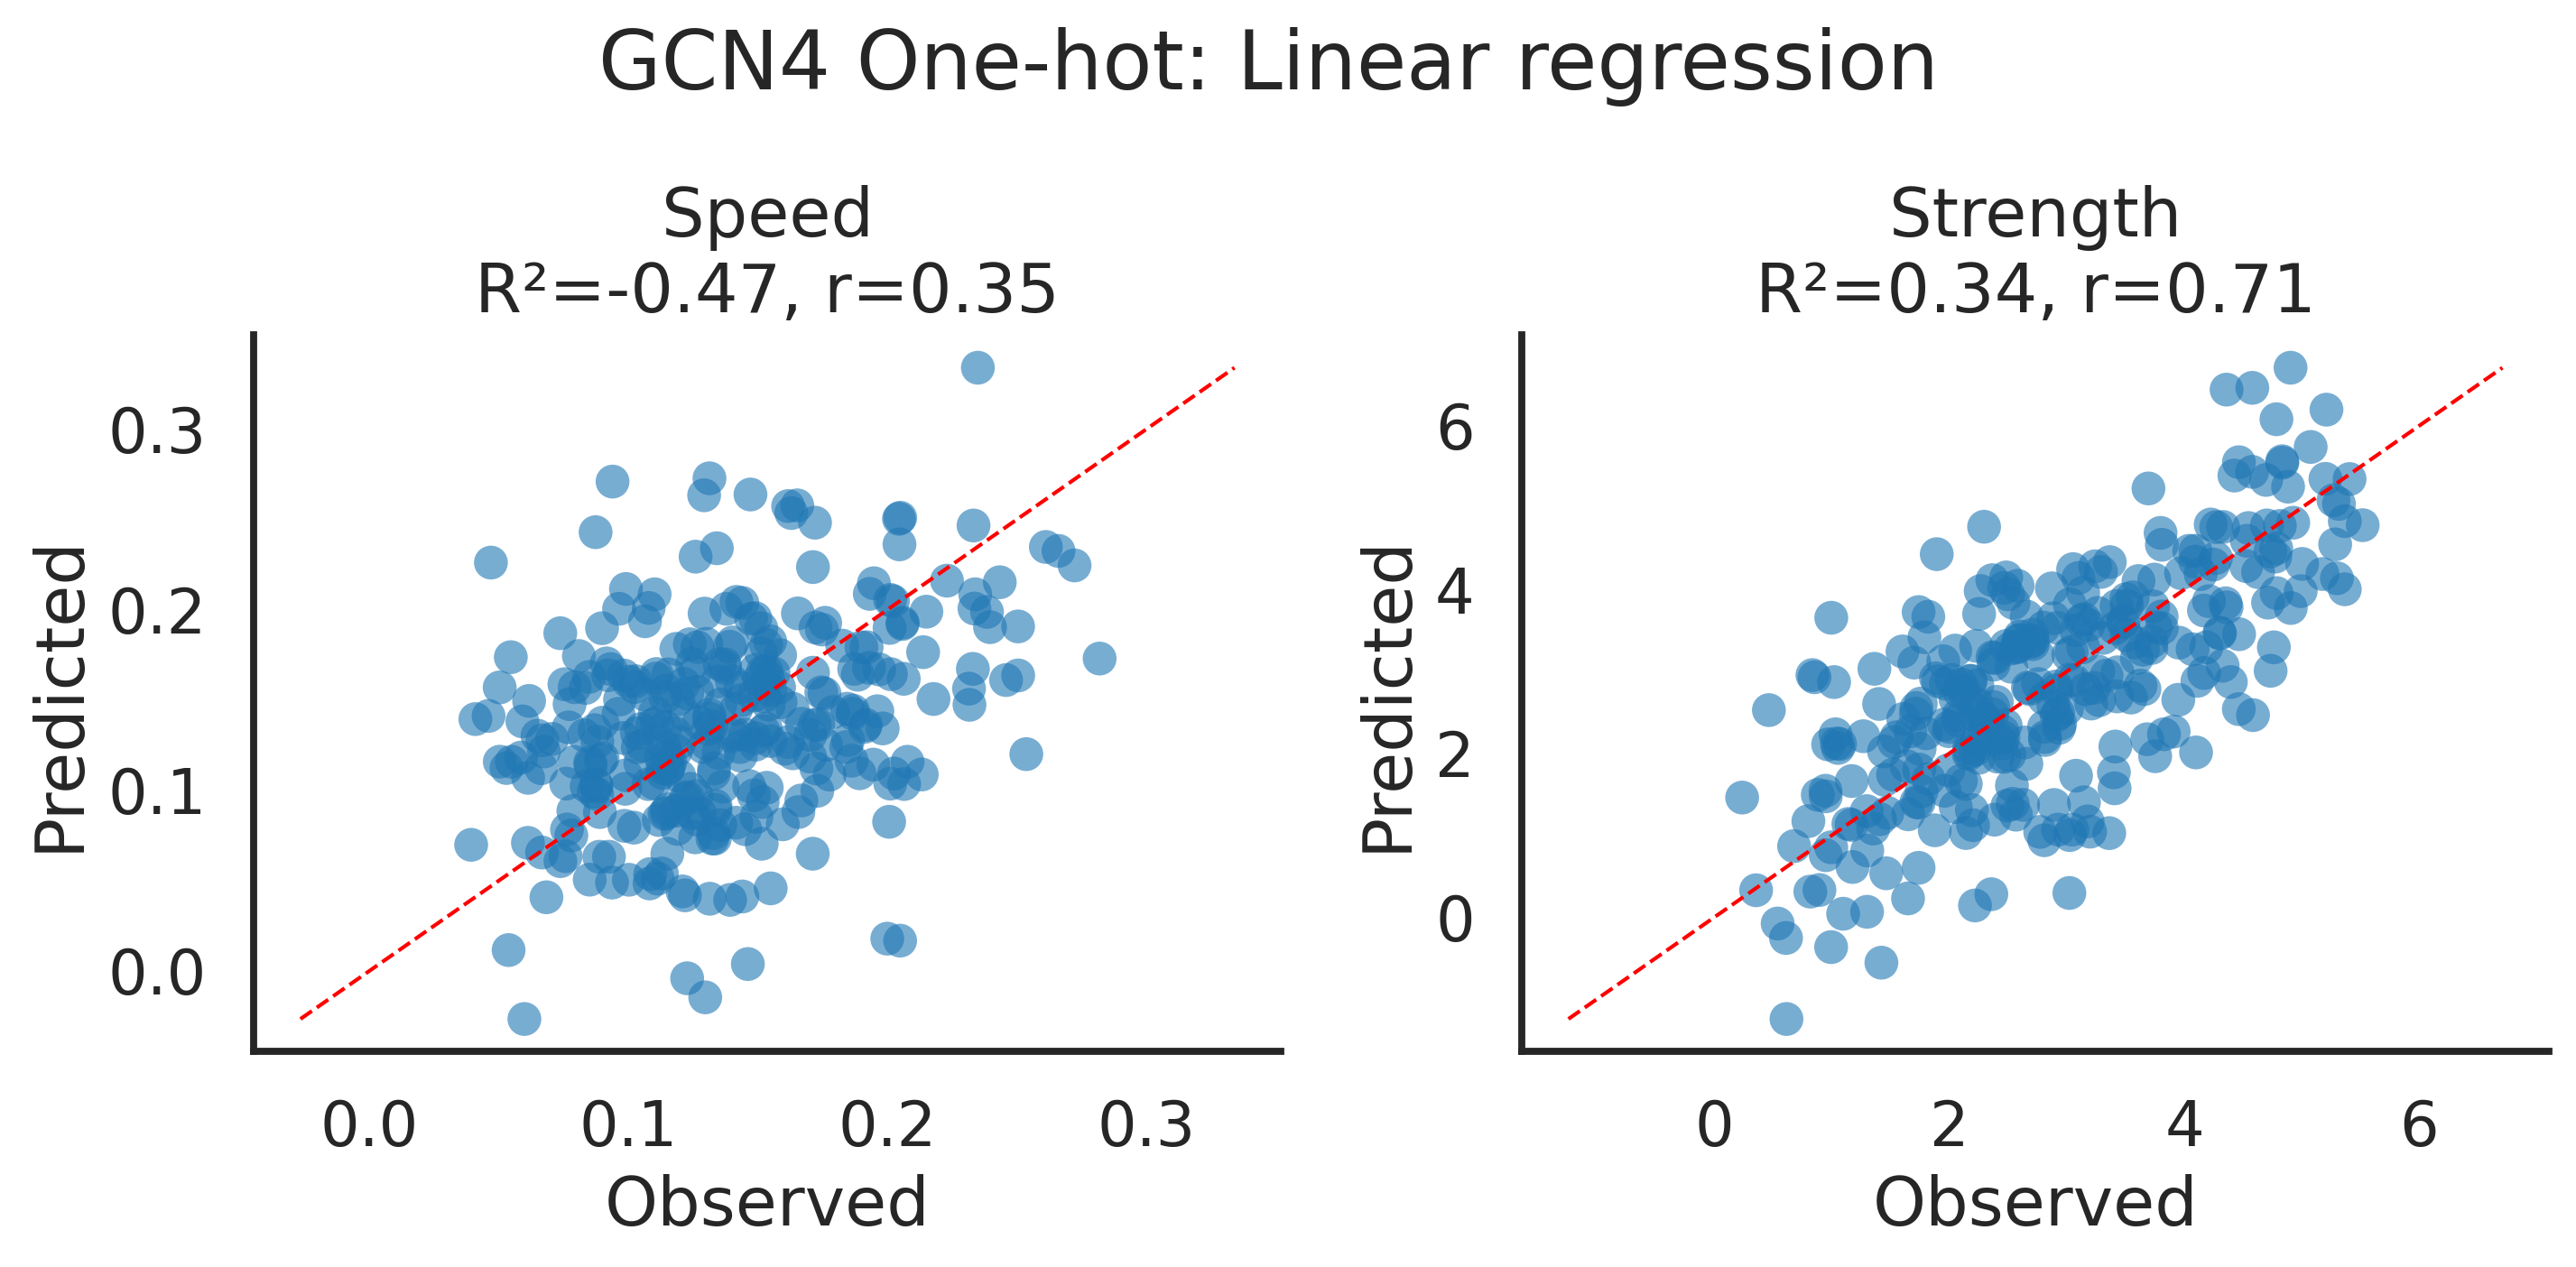

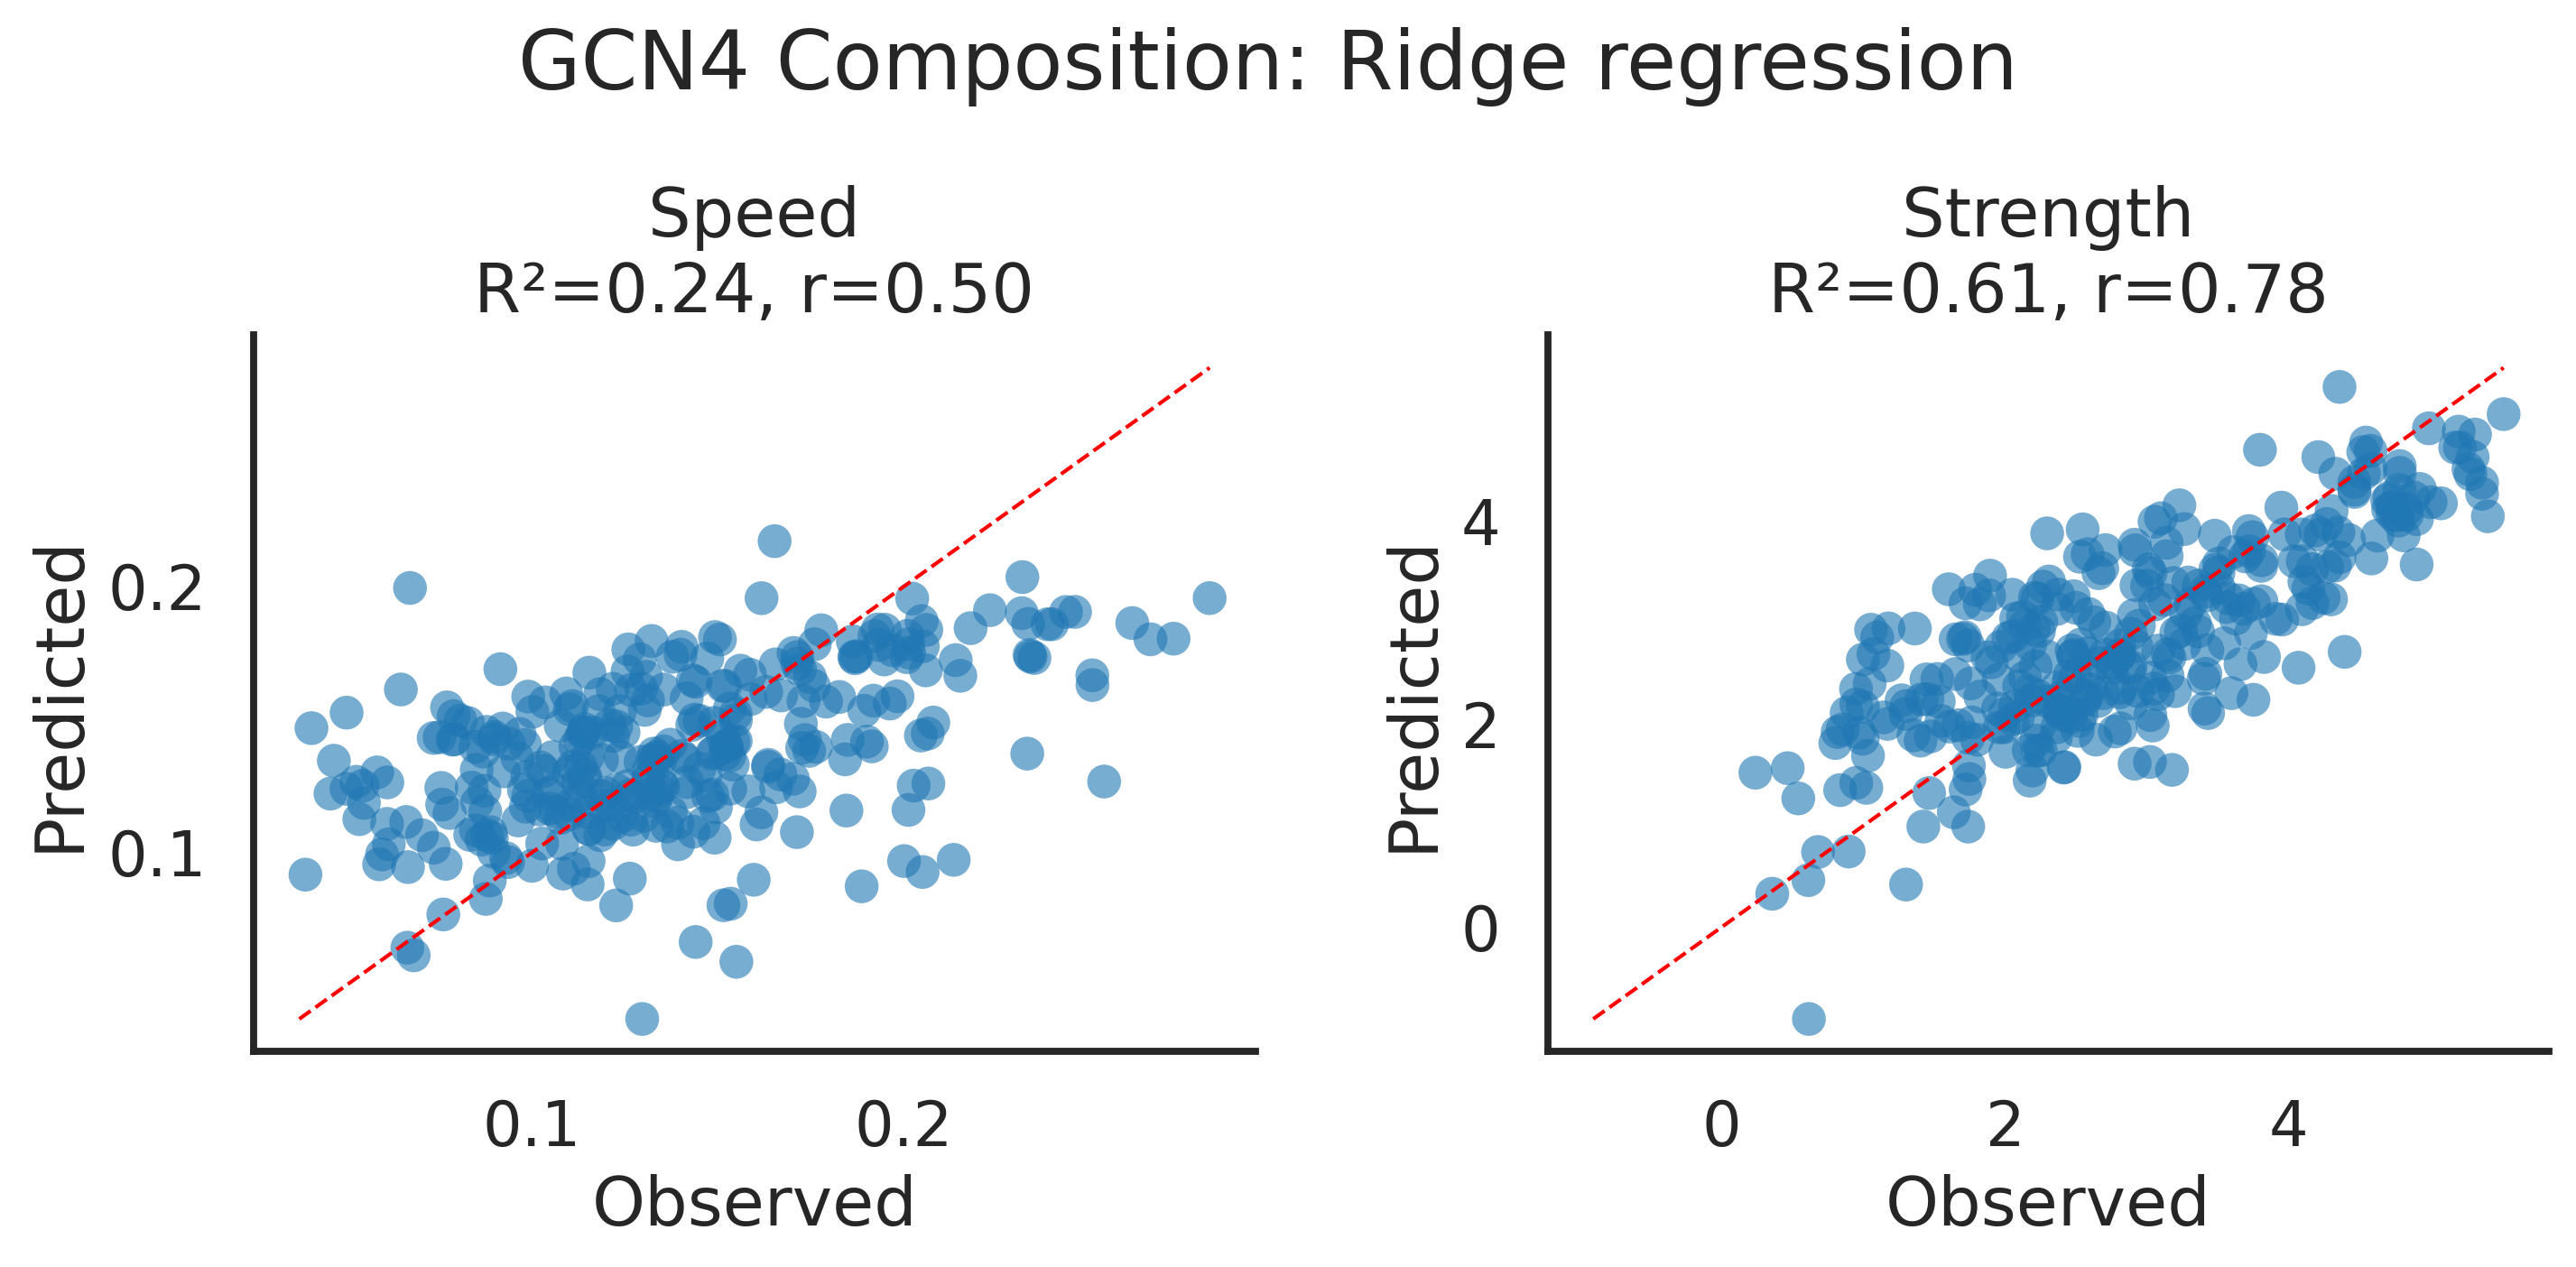

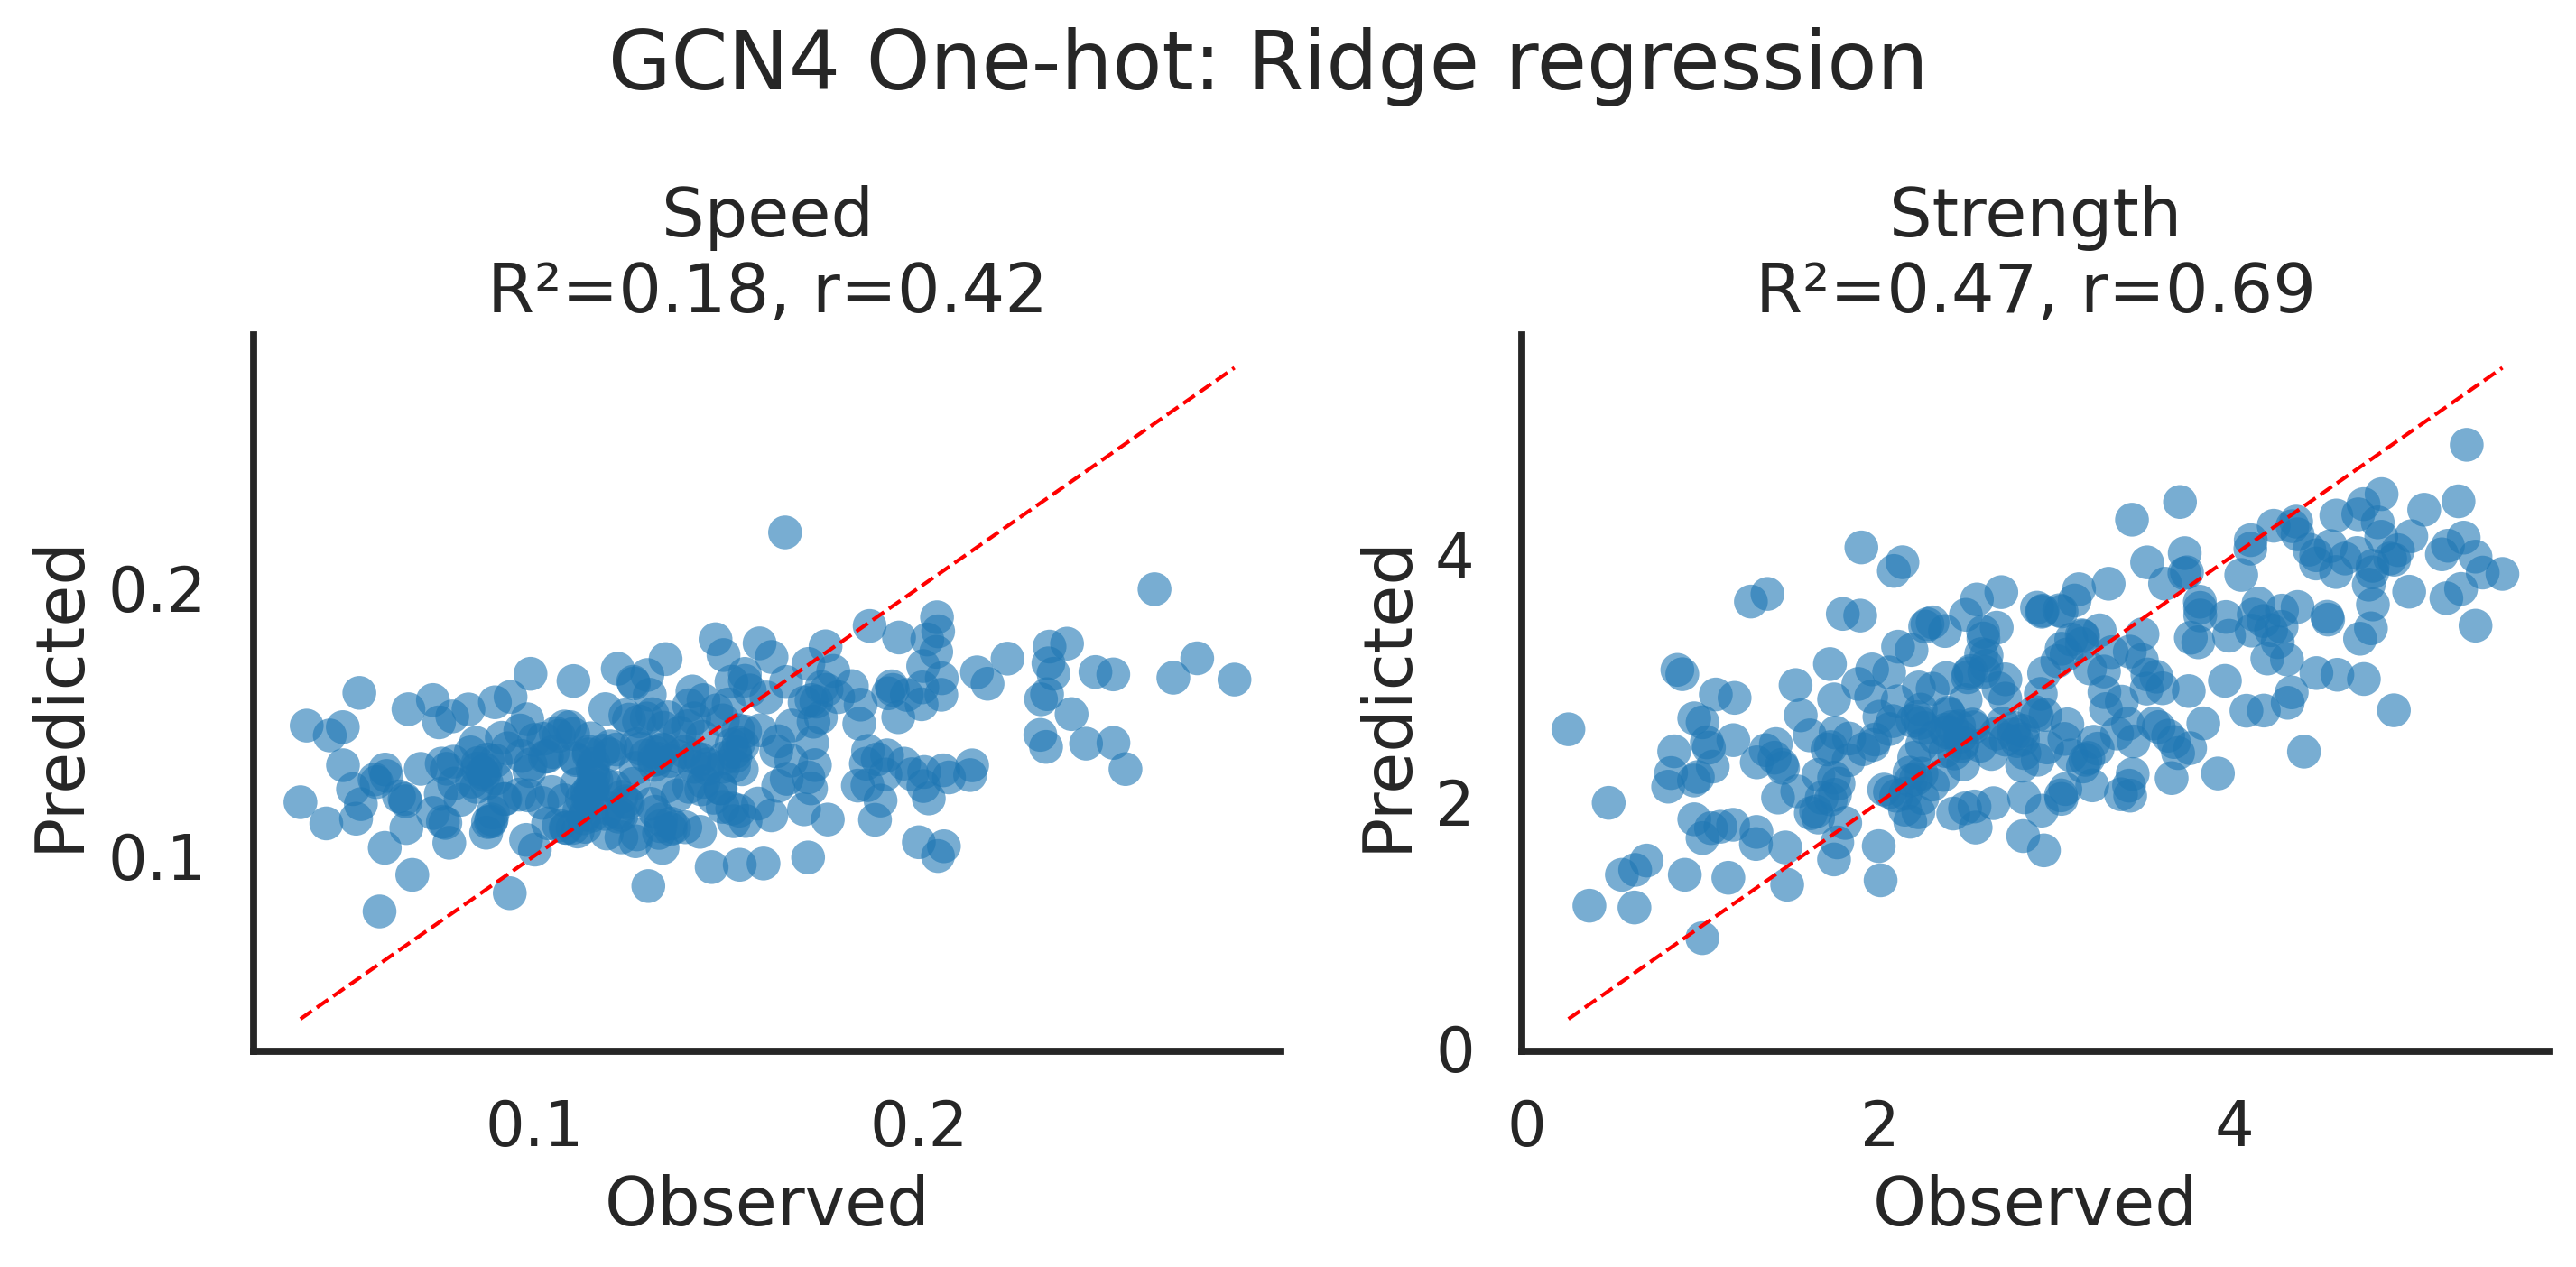

In [206]:
for model_name, artifacts, feature_set, title_prefix, feature_df, top_n in [
    ('Linear regression', composition_linear_artifacts, 'composition', 'Composition', composition_df, 12),
    ('Linear regression', onehot_linear_artifacts, 'one_hot_sequence', 'One-hot', onehot_df, 15),
    ('Ridge regression', composition_ridge_artifacts, 'composition', 'Composition', composition_df, 12),
    ('Ridge regression', onehot_ridge_artifacts, 'one_hot_sequence', 'One-hot', onehot_df, 15),
]:
    plot_prediction_grid(artifacts, feature_set, model_name, title_prefix)

    print(f'Top {feature_set} coefficients for speed ({model_name})')
    display(coefficient_table(
        artifacts[(feature_set, 'speed', model_name)]['estimator'],
        feature_df.columns,
        n=top_n,
    ))

    print(f'Top {feature_set} coefficients for strength ({model_name})')
    display(coefficient_table(
        artifacts[(feature_set, 'strength', model_name)]['estimator'],
        feature_df.columns,
        n=top_n,
    ))


## Do the same features drive speed and strength?

To compare speed and strength on the same scale, this section uses **standardized linear-regression coefficients**. Features in the same-sign quadrants push both traits in the same direction, while opposite-sign features suggest a tradeoff between speed and strength.


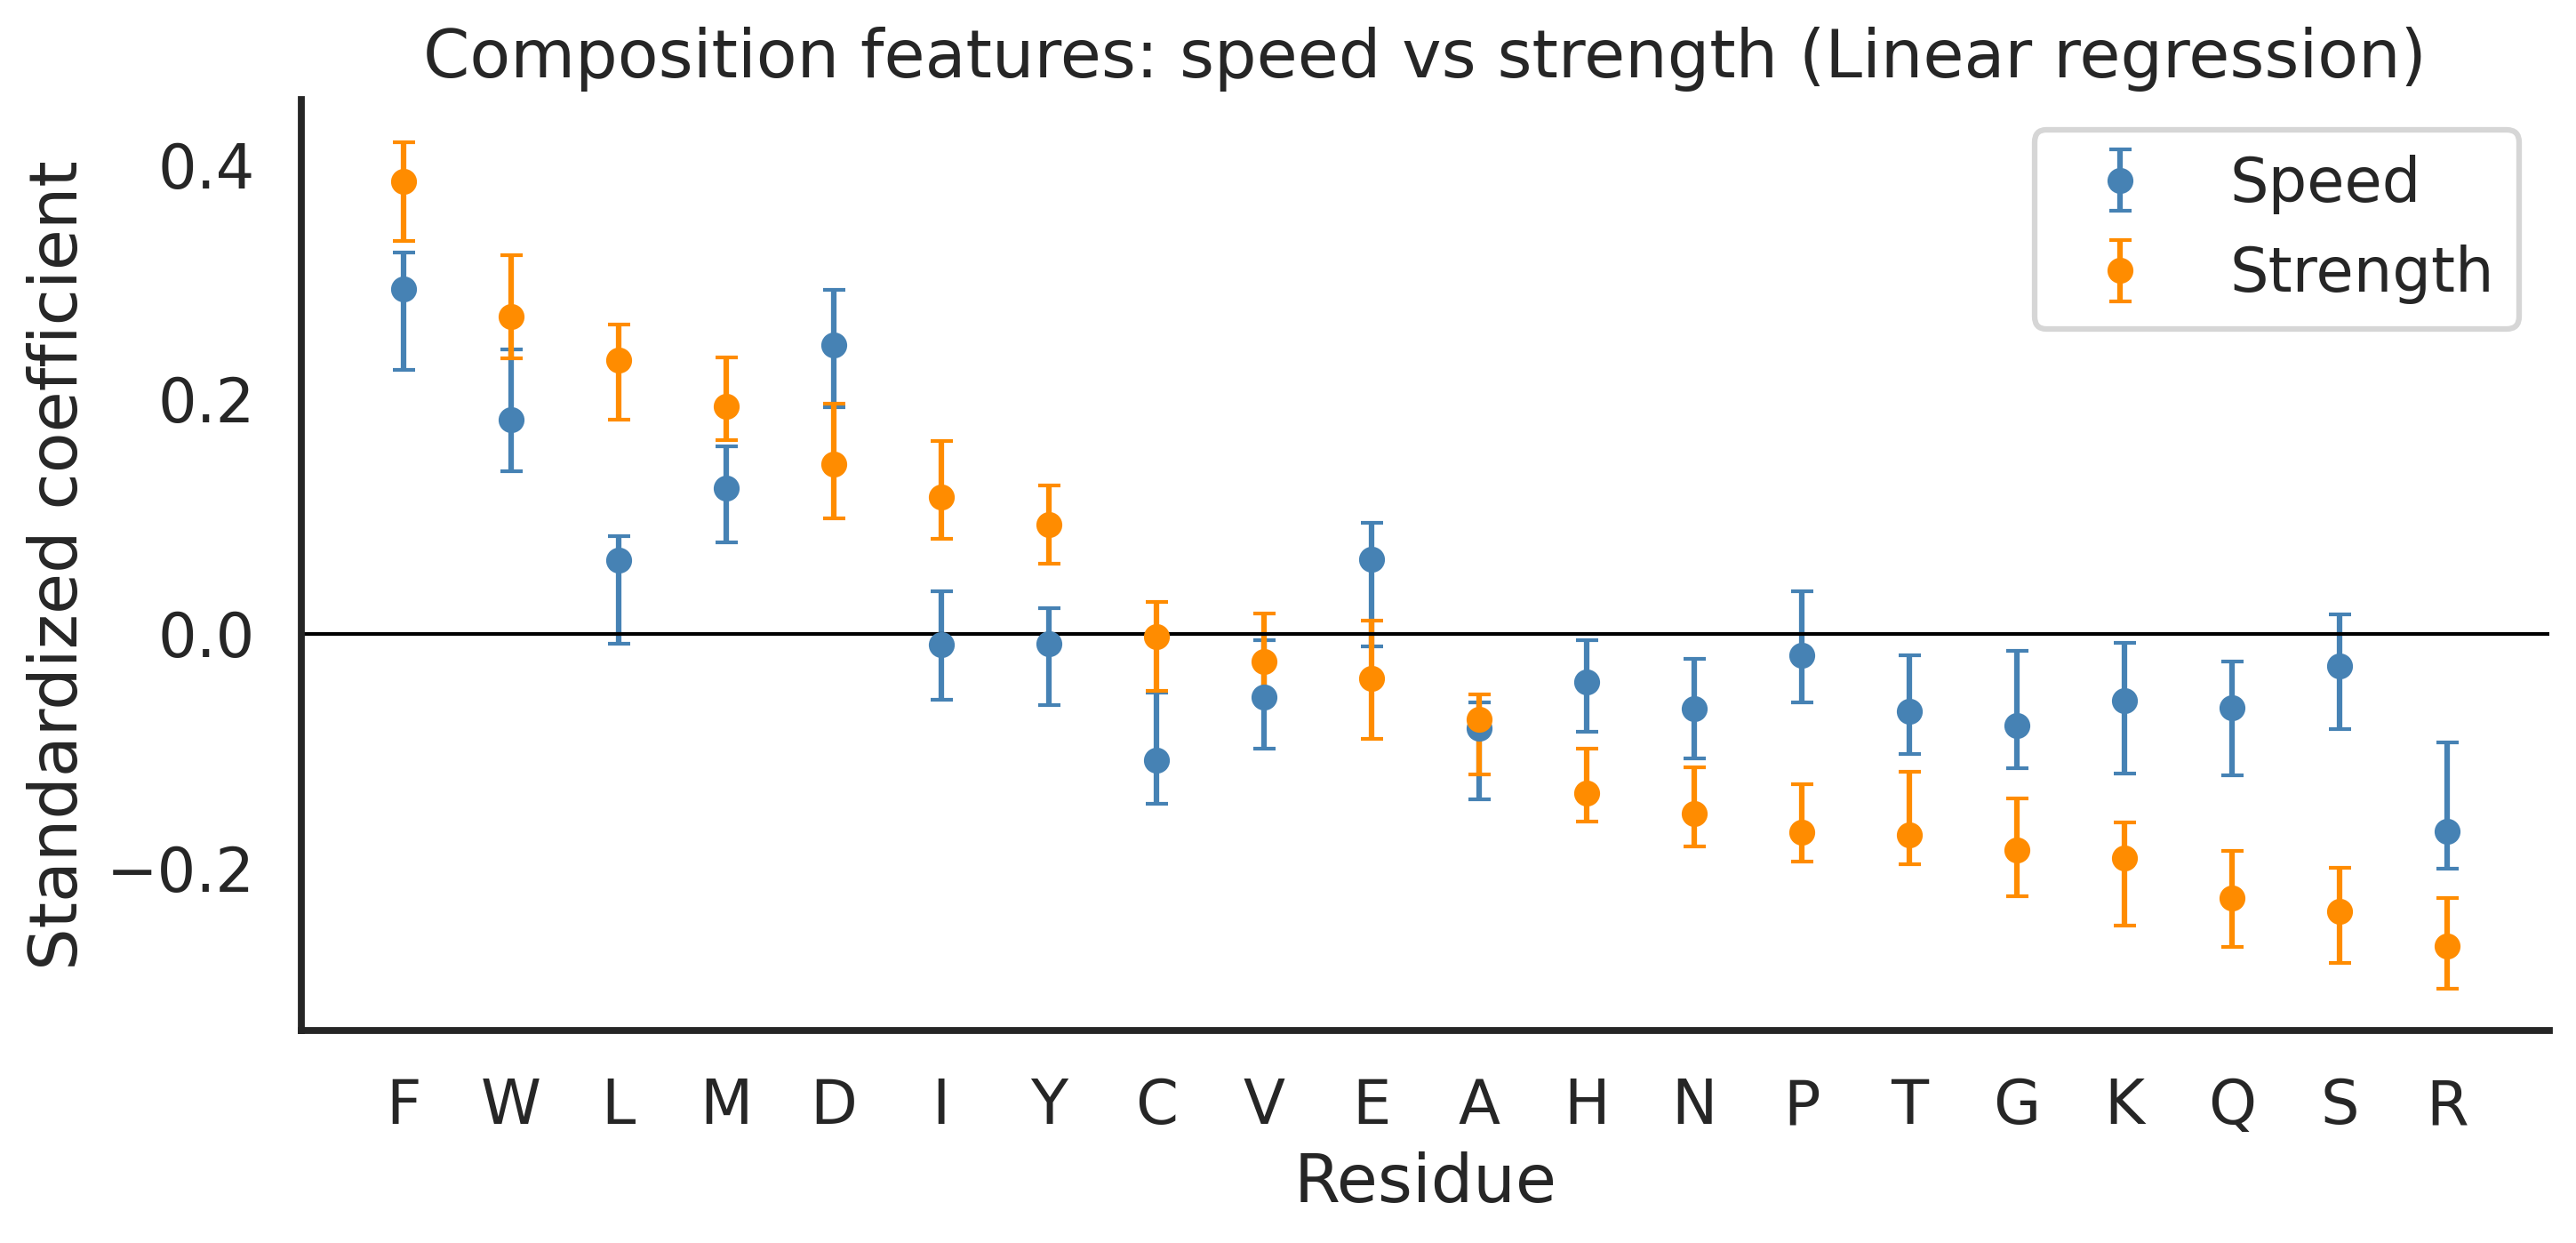

Composition features (Linear regression)


,metric,value
0,Pearson r of standardized coefficients,0.823752
1,Spearman rho of absolute standardized coeffici...,0.336842
2,Fraction of features with the same sign,0.850000


Most shared drivers of speed and strength


,feature,speed_std_coef,strength_std_coef,same_direction,shared_importance
0,F,0.293622,0.385533,True,0.293622
1,W,0.182631,0.270462,True,0.182631
2,R,-0.168996,-0.266743,True,0.168996
3,D,0.246006,0.144233,True,0.144233
7,M,0.124160,0.193485,True,0.124160
9,G,-0.078565,-0.184503,True,0.078565
17,A,-0.080783,-0.073441,True,0.073441
10,T,-0.065997,-0.171584,True,0.065997
12,N,-0.064127,-0.153322,True,0.064127
5,L,0.062953,0.233112,True,0.062953


More speed-specific than strength-specific


...

,feature,speed_std_coef,strength_std_coef,same_direction,shared_importance
1,pos12_F,0.150958,0.135693,True,0.135693
8,pos38_F,0.104682,0.130366,True,0.104682
5,pos35_L,0.102641,0.134181,True,0.102641
2,pos02_F,0.145301,0.101364,True,0.101364
10,pos05_F,0.127450,0.100688,True,0.100688
26,pos33_W,0.096029,0.102314,True,0.096029
48,pos11_F,0.086351,0.094318,True,0.086351
36,pos16_C,0.085157,0.098839,True,0.085157
37,pos31_F,0.083968,0.098782,True,0.083968
82,pos16_S,-0.083565,-0.084395,True,0.083565


More speed-specific than strength-specific


,feature,speed_std_coef,strength_std_coef,importance_gap
6,pos02_D,0.131405,0.025527,0.105878
19,pos25_D,0.111220,0.032480,0.078741
81,pos26_A,-0.084416,-0.007479,0.076936
101,pos02_S,0.080307,-0.003836,0.076471
57,pos15_D,0.091831,0.015702,0.076130
76,pos21_L,0.085842,-0.011109,0.074733
15,pos33_F,0.113907,0.039649,0.074258
34,pos21_D,0.099051,0.025273,0.073779
96,pos02_G,0.081099,0.007993,0.073106
110,pos39_V,-0.078455,-0.005569,0.072886


More strength-specific than speed-specific


,feature,speed_std_coef,strength_std_coef,importance_gap
0,pos23_F,0.044073,0.161124,-0.117050
7,pos26_W,0.023713,0.131042,-0.107328
9,pos14_F,0.032668,0.128446,-0.095778
47,pos11_S,0.004237,-0.094340,-0.090104
42,pos20_S,-0.008002,-0.096227,-0.088225
24,pos11_T,-0.017903,-0.102974,-0.085071
29,pos25_F,0.017263,0.101416,-0.084153
83,pos22_F,-0.001588,0.084357,-0.082769
11,pos13_W,0.036385,0.118159,-0.081774
35,pos29_W,0.019022,0.098883,-0.079861


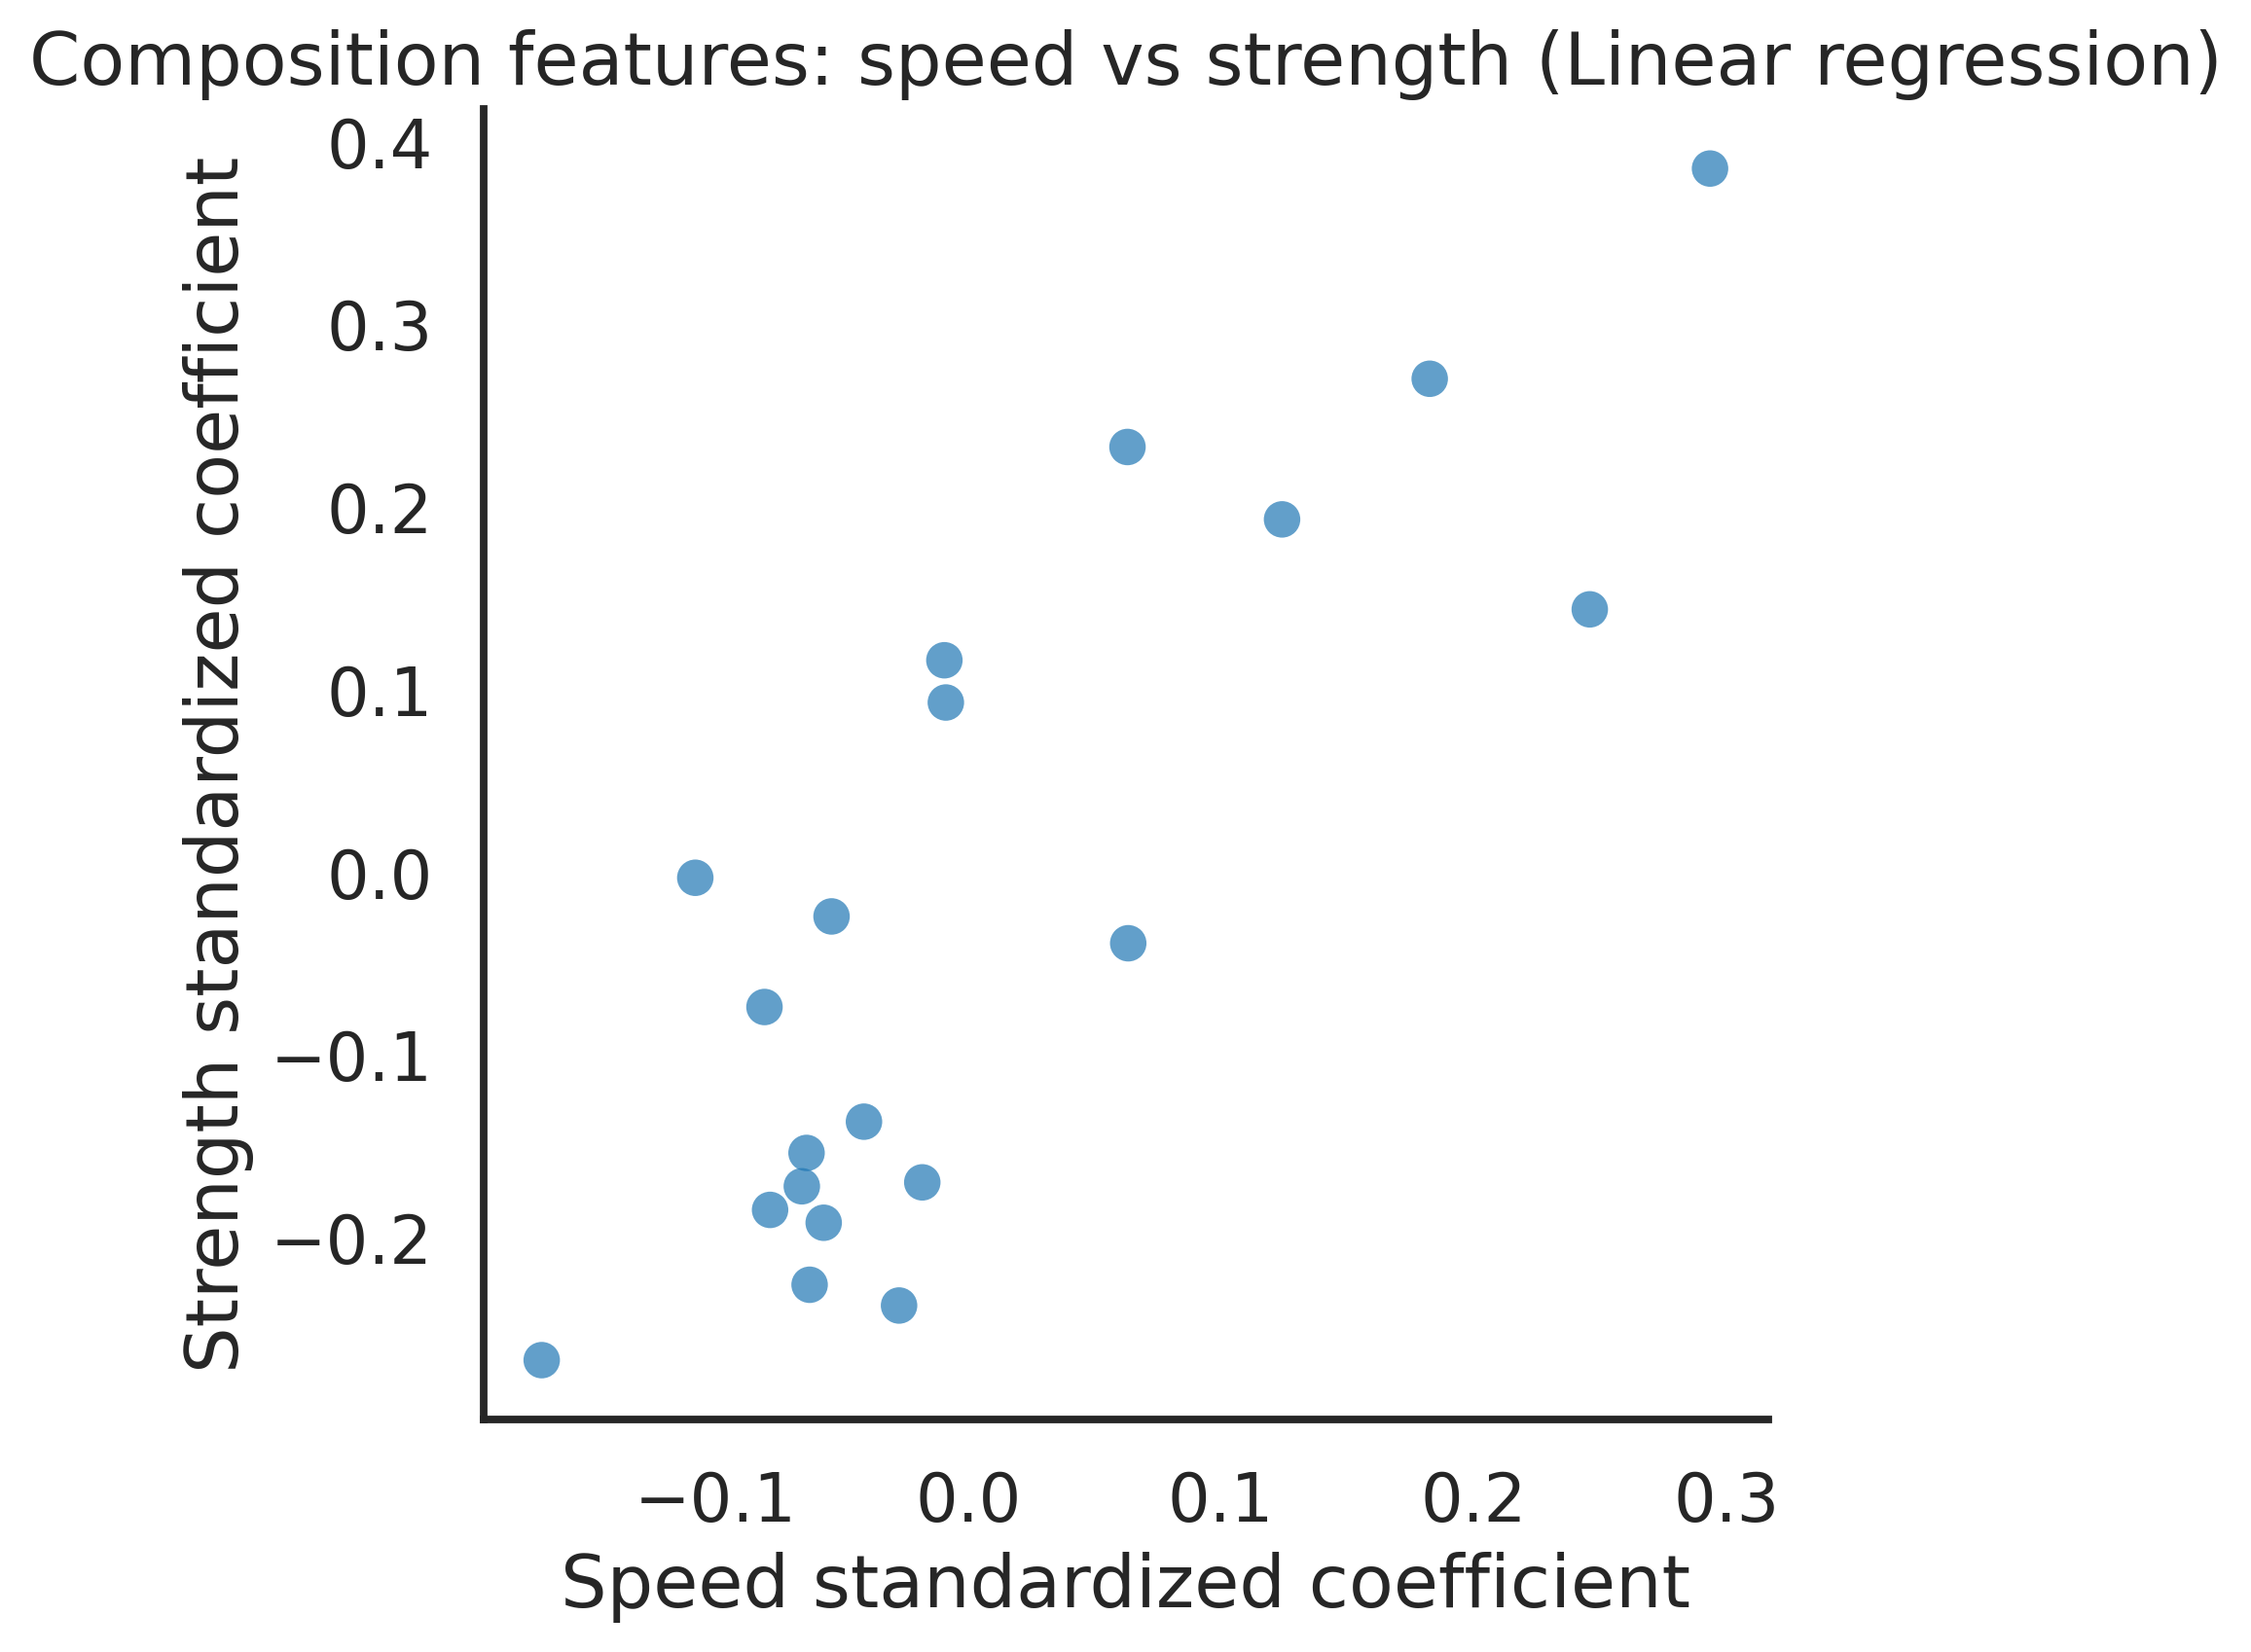

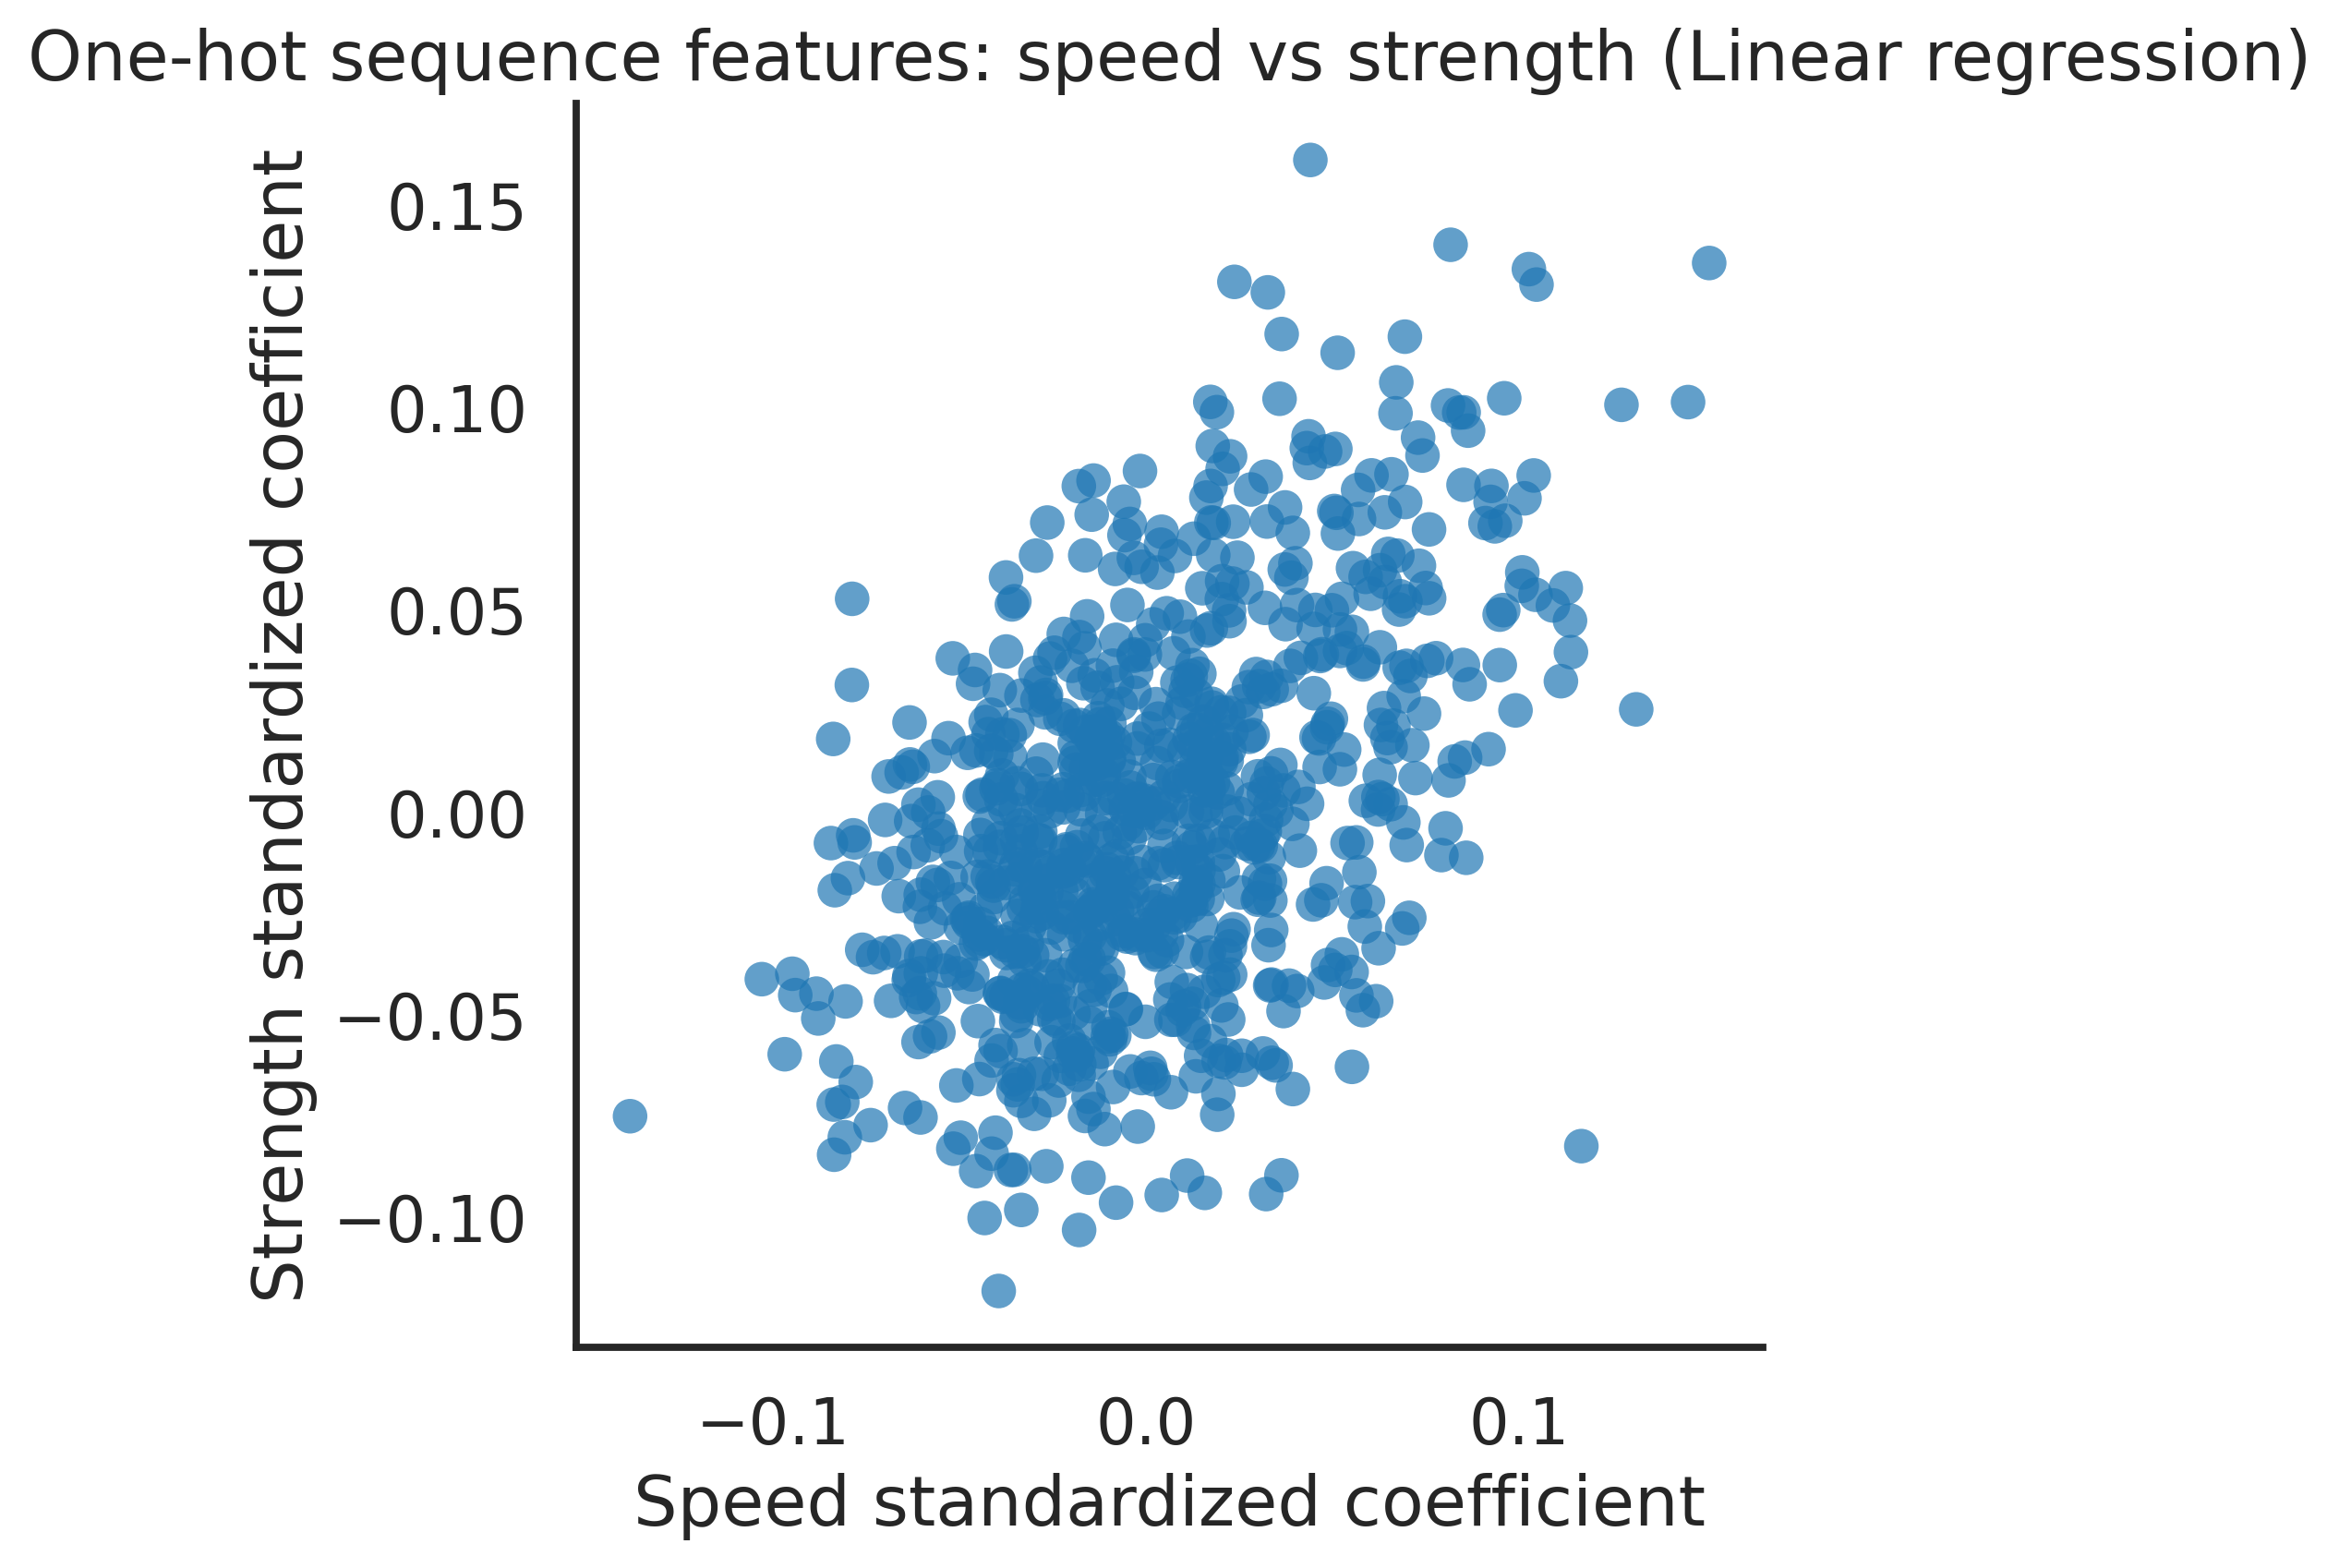

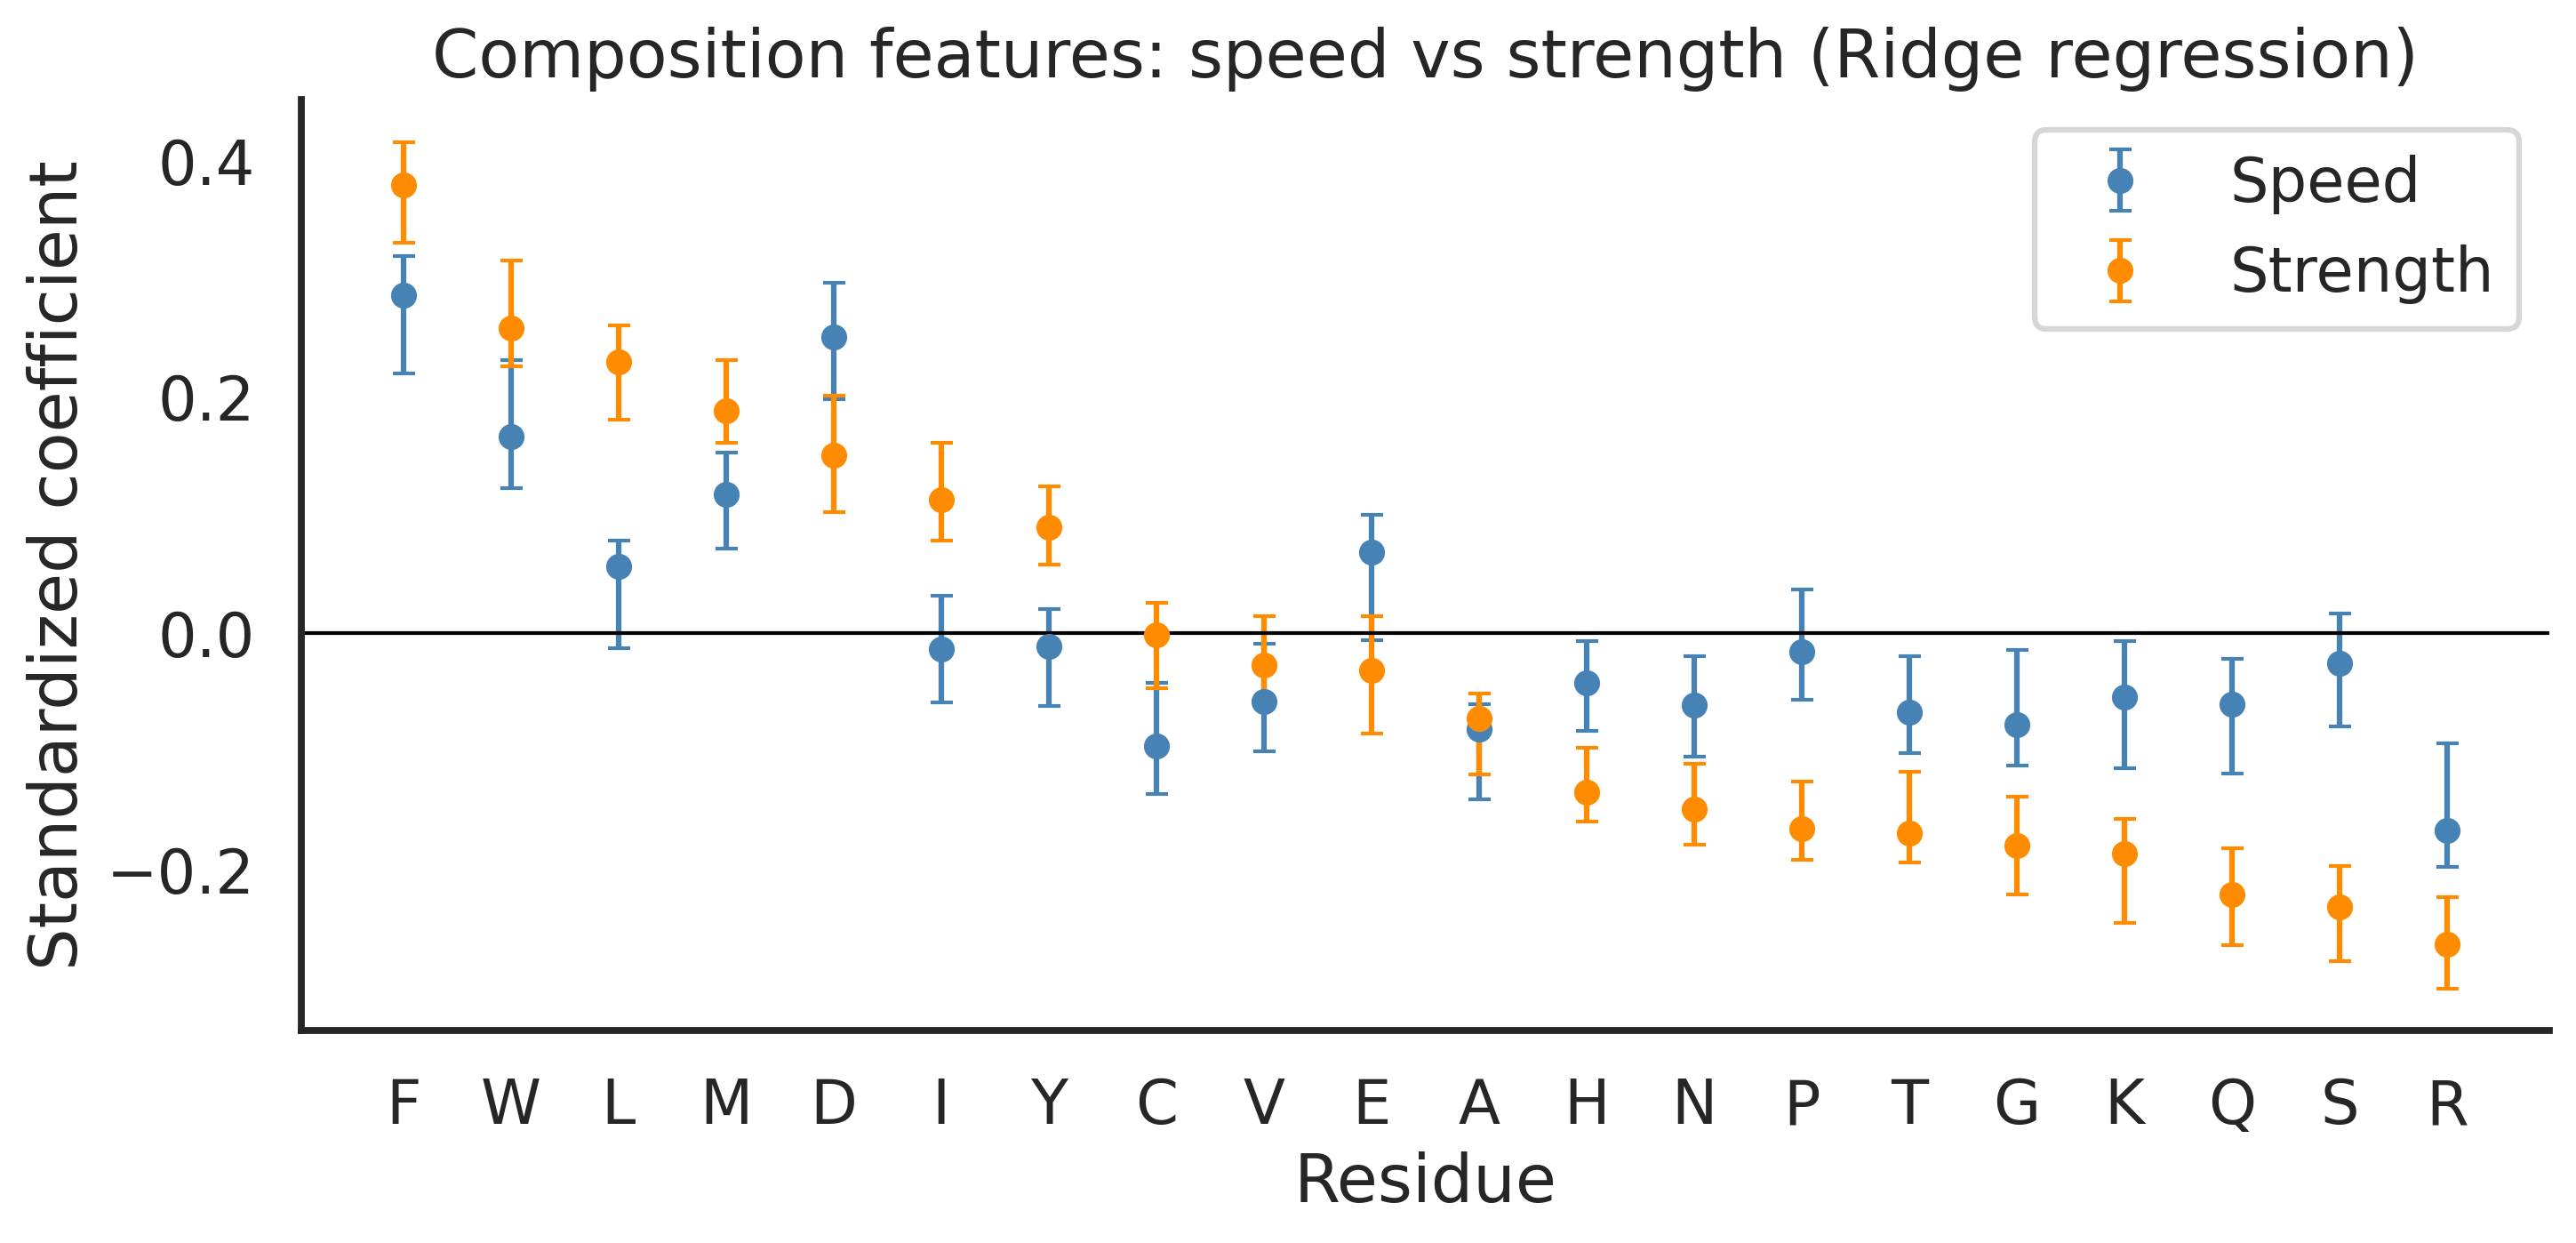

Composition features (Ridge regression)


,metric,value
0,Pearson r of standardized coefficients,0.817859
1,Spearman rho of absolute standardized coeffici...,0.290226
2,Fraction of features with the same sign,0.850000


Most shared drivers of speed and strength


,feature,speed_std_coef,strength_std_coef,same_direction,shared_importance
0,F,0.286176,0.380057,True,0.286176
1,R,-0.166990,-0.263103,True,0.166990
2,W,0.166438,0.258360,True,0.166438
3,D,0.251385,0.151224,True,0.151224
7,M,0.117460,0.188628,True,0.117460
9,G,-0.077254,-0.179569,True,0.077254
17,A,-0.081083,-0.071856,True,0.071856
10,T,-0.066550,-0.169391,True,0.066550
12,N,-0.060755,-0.148727,True,0.060755
6,Q,-0.059622,-0.220924,True,0.059622


More speed-specific than strength-specific


...

,feature,speed_std_coef,strength_std_coef,same_direction,shared_importance
22,pos25_D,0.053419,0.053760,True,0.053419
0,pos13_D,0.051971,0.073705,True,0.051971
5,pos15_F,0.051163,0.064574,True,0.051163
4,pos10_D,0.048594,0.064864,True,0.048594
19,pos15_D,0.057015,0.047794,True,0.047794
9,pos07_D,0.046688,0.062254,True,0.046688
30,pos30_D,0.046230,0.051143,True,0.046230
26,pos05_F,0.044607,0.051966,True,0.044607
33,pos08_F,0.043841,0.049307,True,0.043841
45,pos11_D,0.045920,0.043306,True,0.043306


More speed-specific than strength-specific


,feature,speed_std_coef,strength_std_coef,importance_gap
84,pos02_T,0.035381,0.002476,0.032905
66,pos16_L,-0.039397,-0.008181,0.031217
41,pos24_S,-0.046813,-0.021180,0.025633
152,pos04_A,-0.027306,-0.005032,0.022274
197,pos20_P,0.023827,-0.001851,0.021976
189,pos01_T,0.024466,0.002961,0.021505
161,pos12_L,-0.026387,0.005372,0.021015
240,pos06_P,0.021195,0.000614,0.020581
182,pos31_P,-0.024975,-0.004627,0.020349
223,pos03_A,0.022022,-0.001783,0.020238


More strength-specific than speed-specific


,feature,speed_std_coef,strength_std_coef,importance_gap
18,pos17_F,0.008885,0.057861,-0.048976
15,pos38_L,0.010406,0.058857,-0.048451
27,pos31_D,0.008223,0.051801,-0.043578
39,pos19_S,-0.005210,-0.047961,-0.042751
31,pos08_P,-0.008630,-0.051111,-0.042481
32,pos28_S,-0.006929,-0.049343,-0.042415
1,pos11_T,-0.030279,-0.071677,-0.041398
14,pos20_D,0.018236,0.059475,-0.041240
47,pos25_L,-0.003505,0.044168,-0.040664
25,pos23_F,0.012638,0.052330,-0.039693


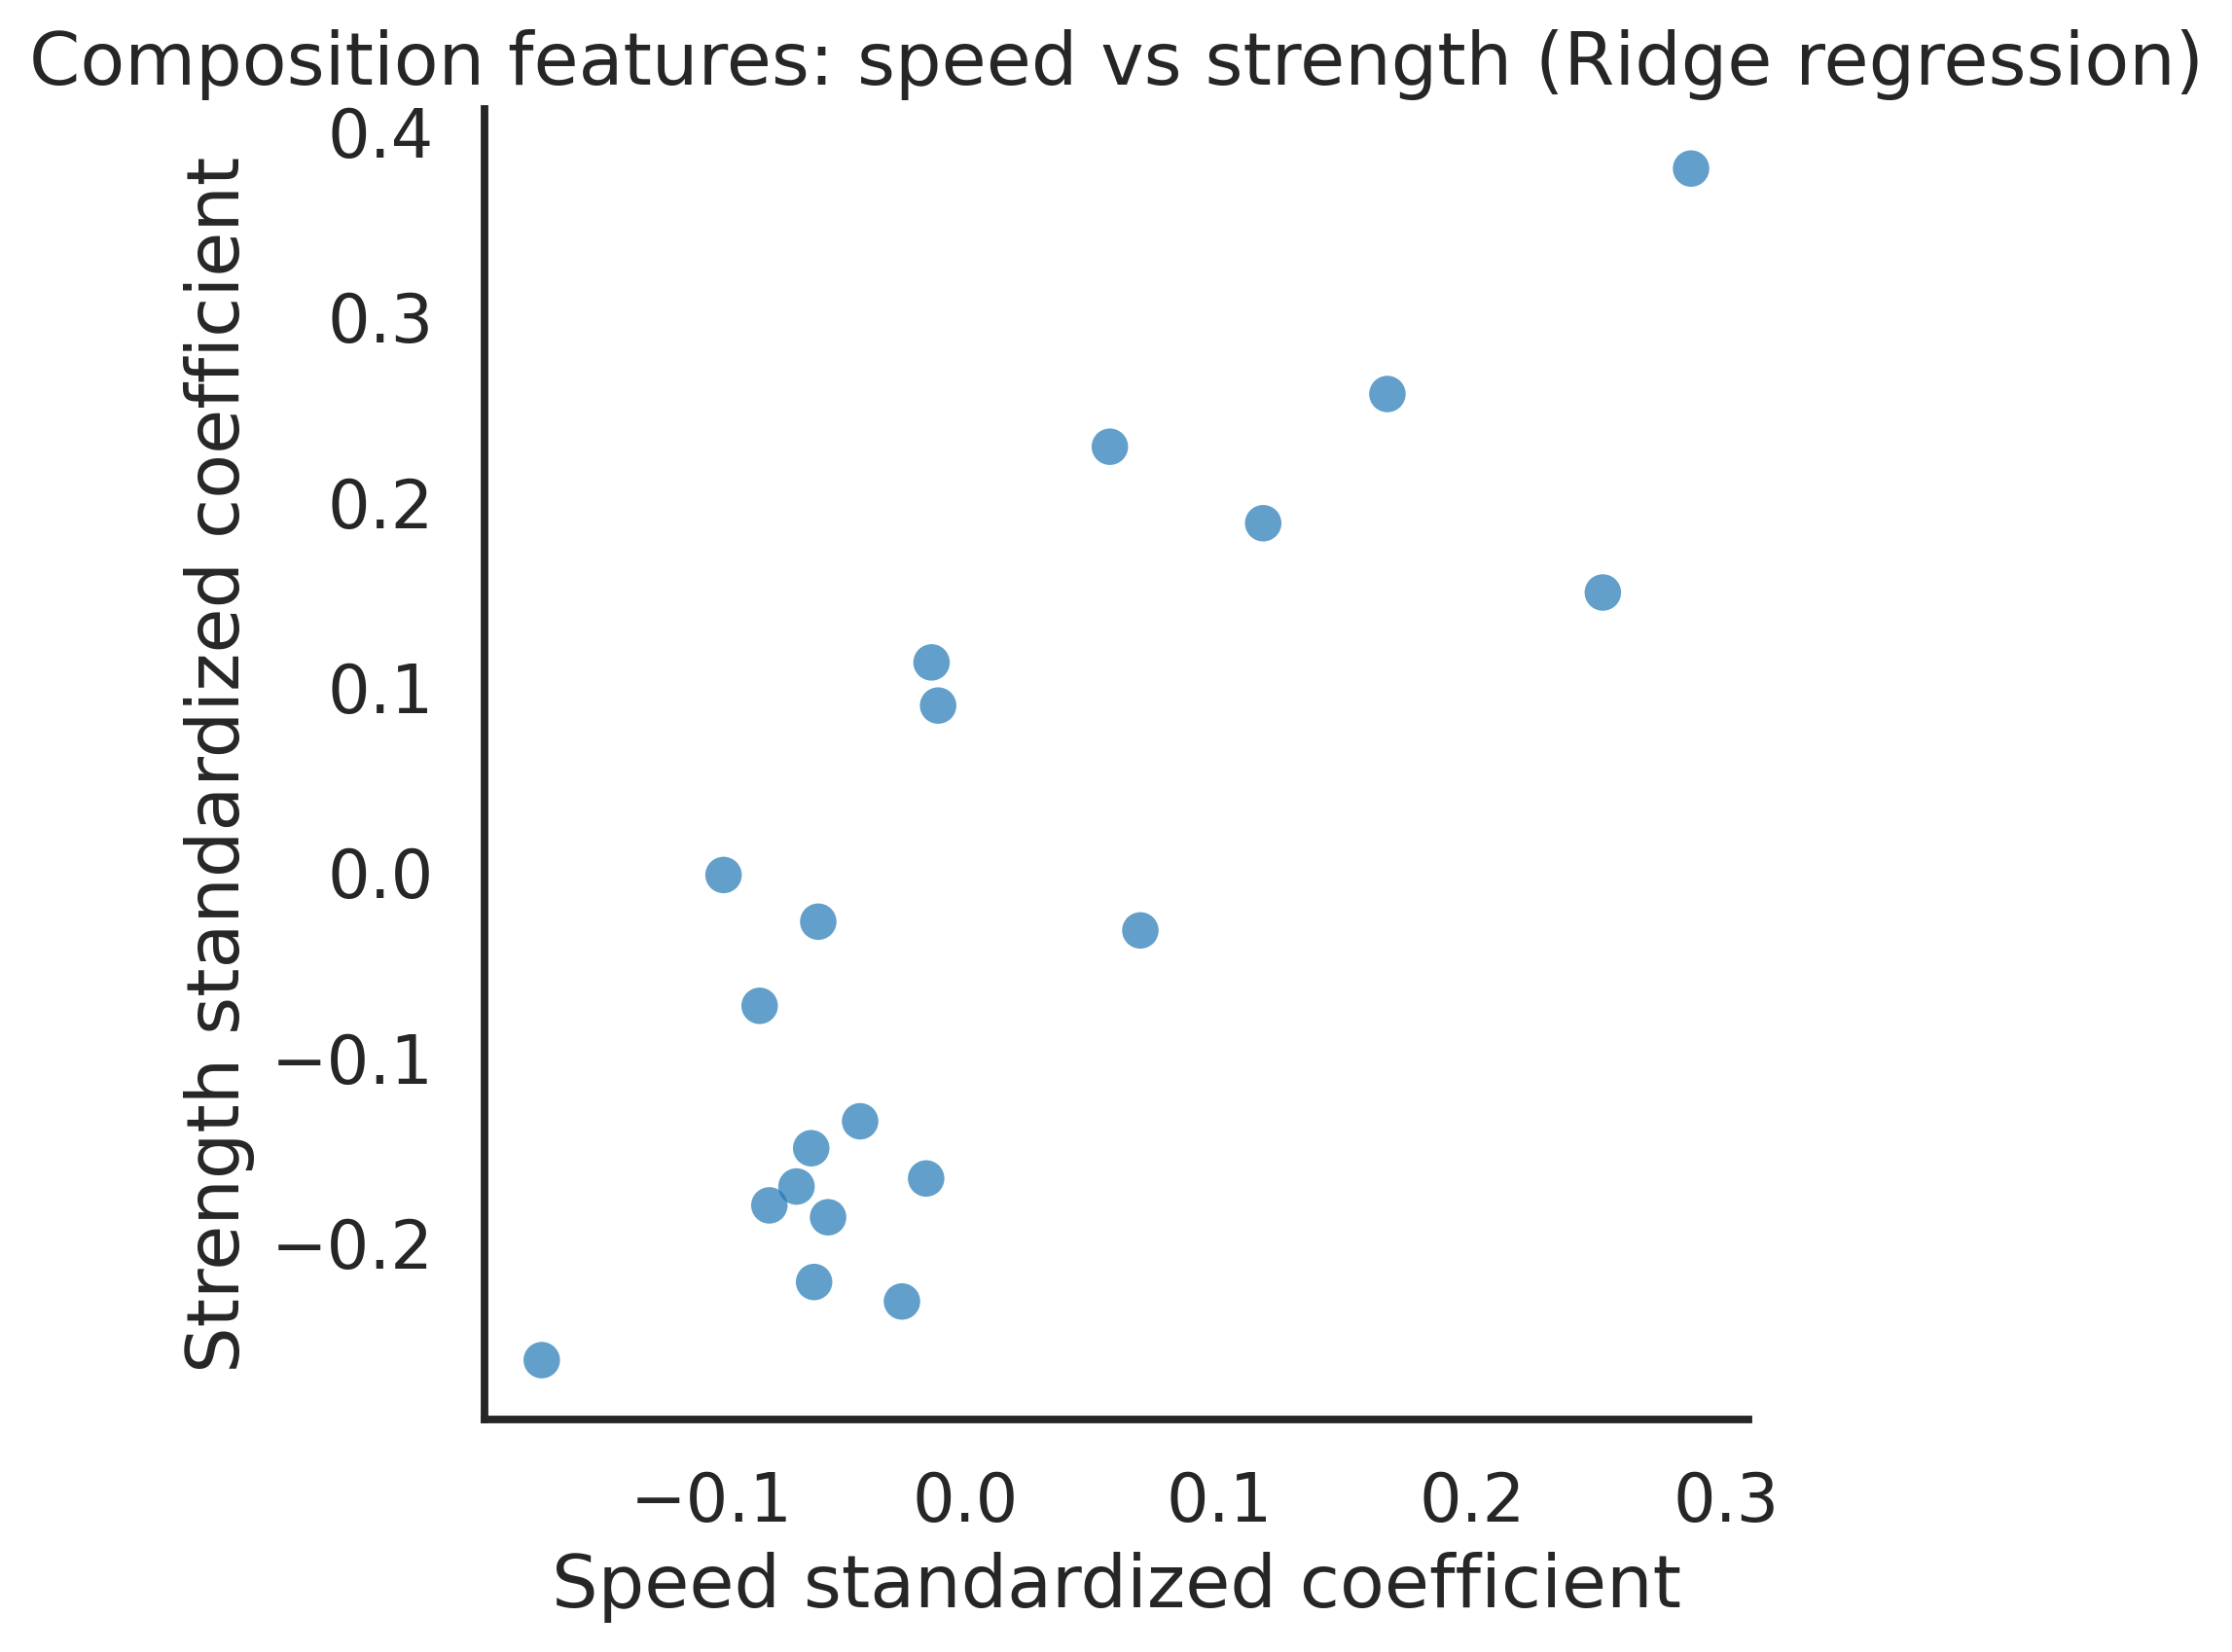

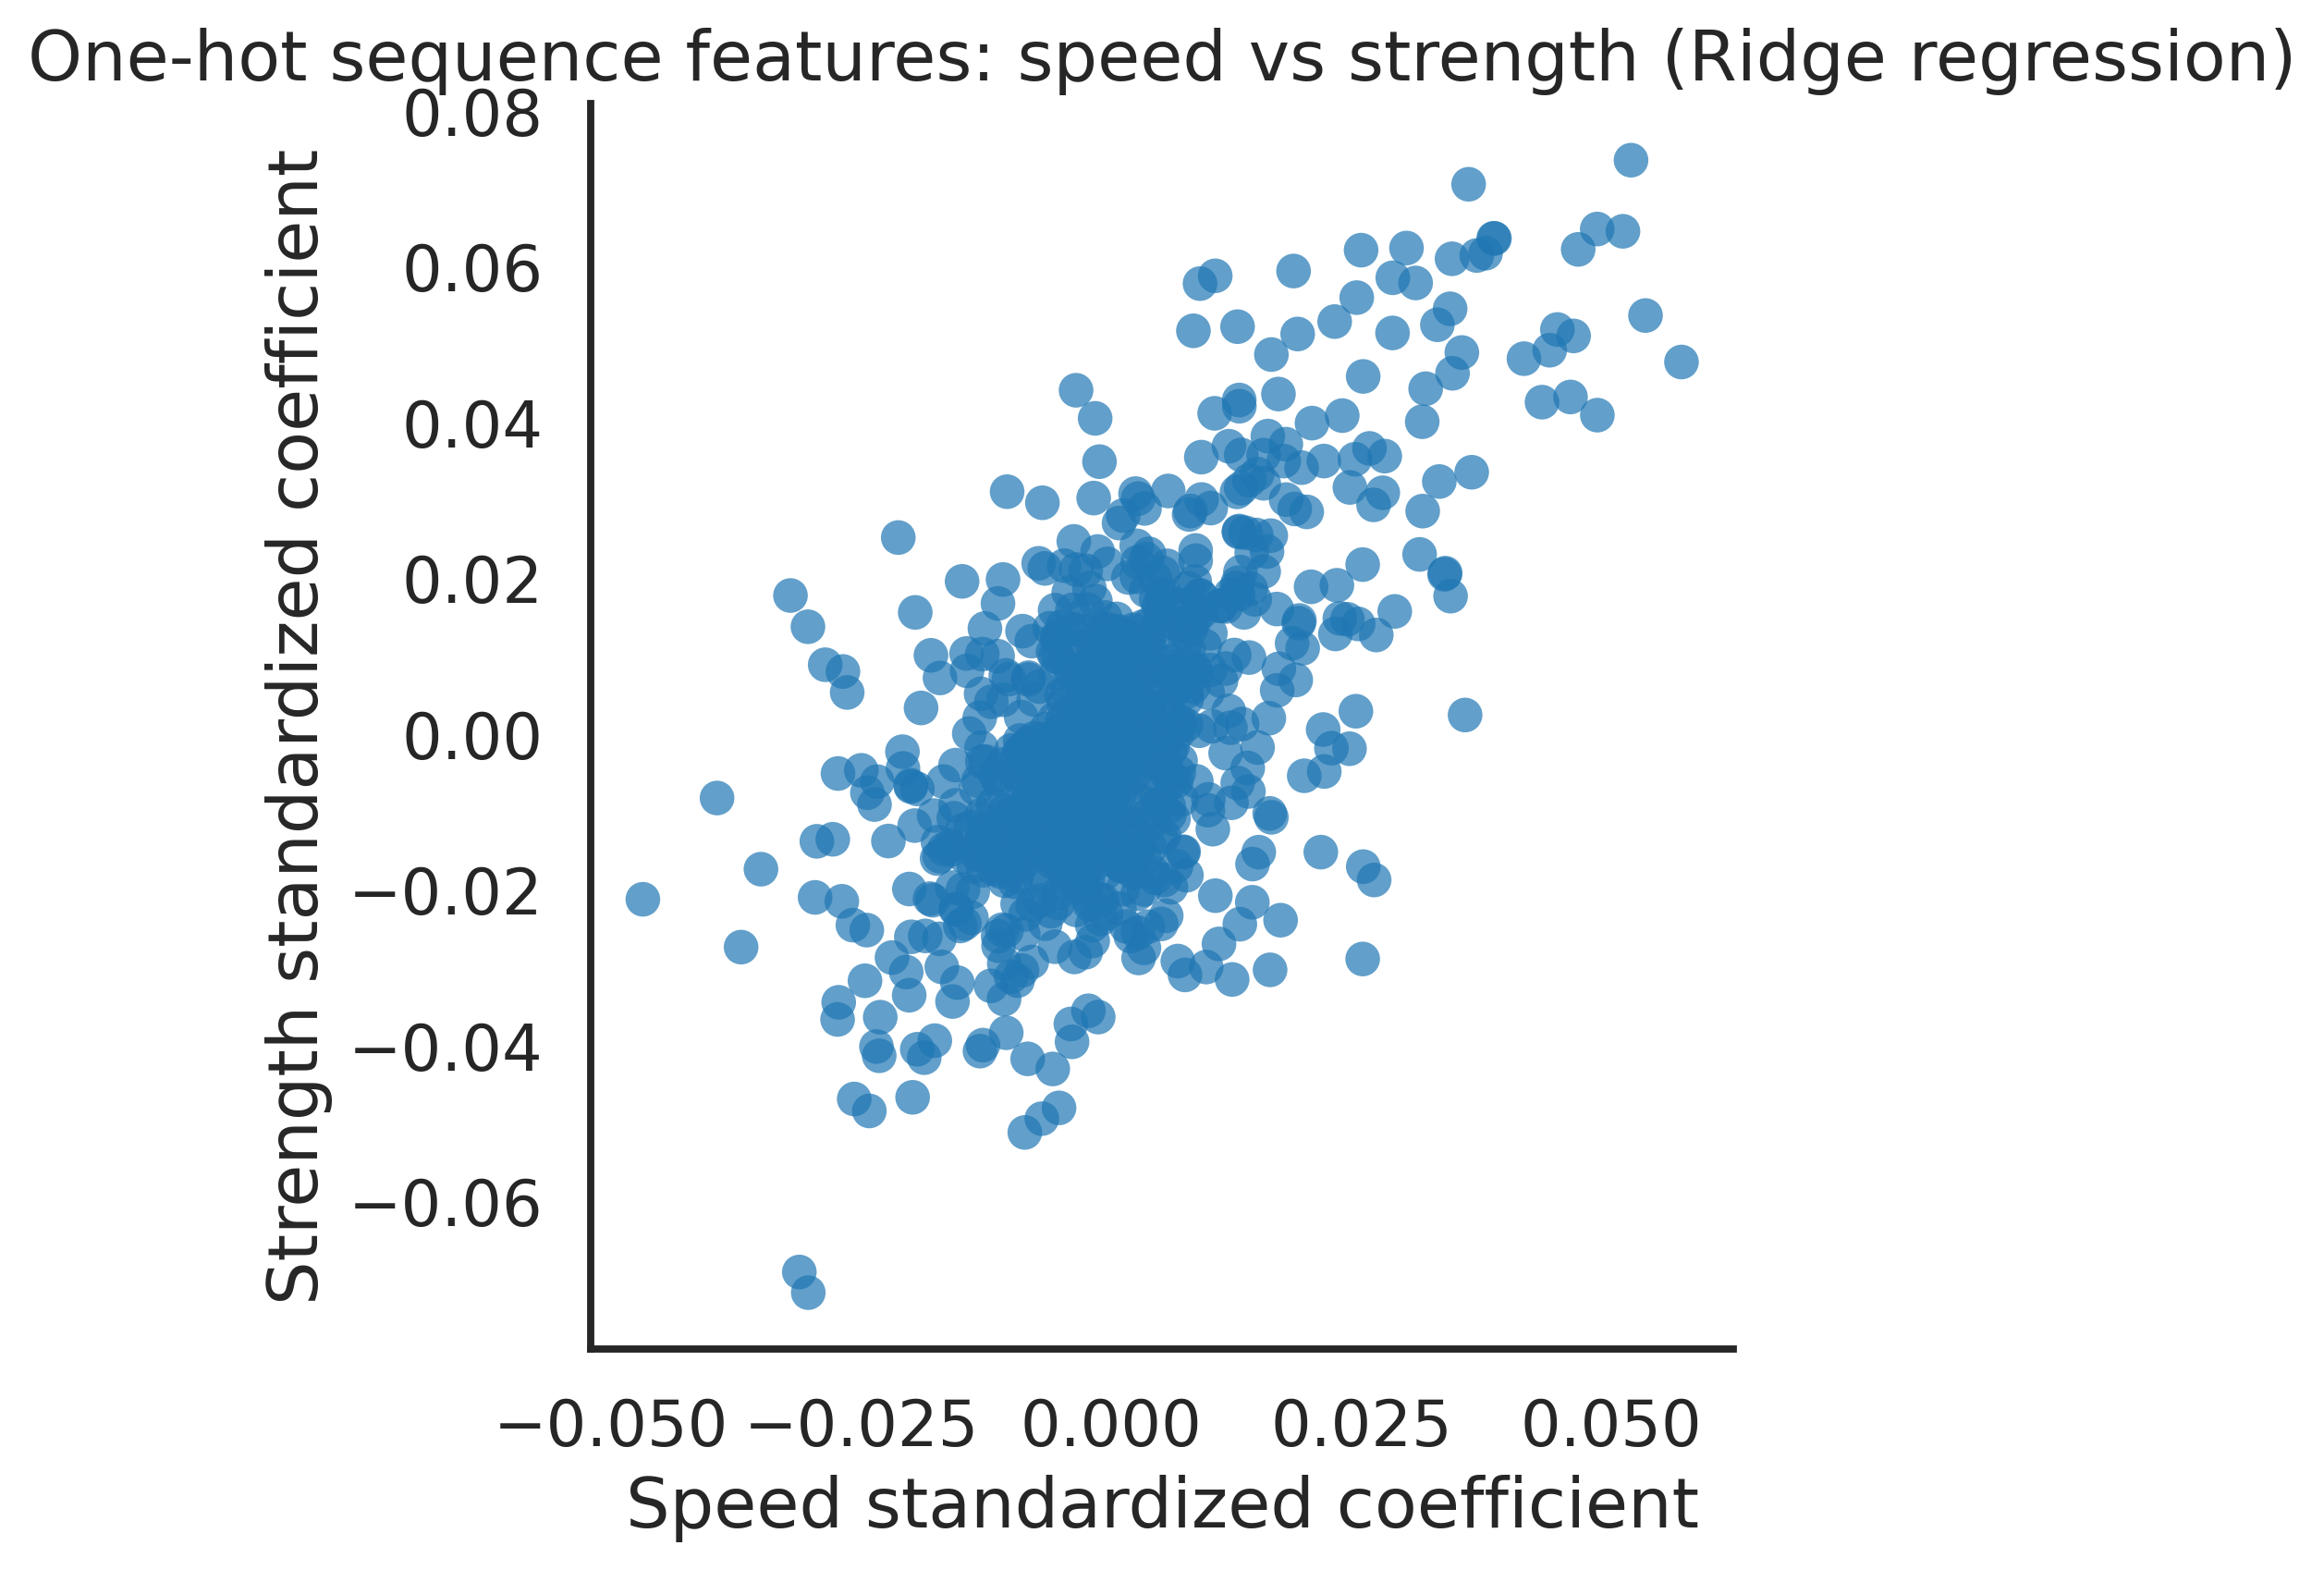

In [207]:
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------
# Standardized coefficient table for a fitted model
# ---------------------------------------------------------
def standardized_coefficient_table(model, X, y):
    coef = pd.Series(np.asarray(model.coef_).reshape(-1), index=X.columns)
    feature_std = X.std(ddof=0).replace(0, np.nan)
    y_std = np.std(y)
    standardized = (coef * feature_std / y_std).fillna(0.0)

    return pd.DataFrame({
        'feature': X.columns,
        'coef': coef.reindex(X.columns).to_numpy(),
        'std_coef': standardized.reindex(X.columns).to_numpy(),
    }).assign(abs_std_coef=lambda df: df['std_coef'].abs())


# ---------------------------------------------------------
# Bootstrap standardized coefficients for linear models
# ---------------------------------------------------------
def bootstrap_standardized_coefficients(X, y, model_builder, n_boot=500, random_state=42):
    rng = np.random.RandomState(random_state)

    X_df = X.copy()
    X_array = np.asarray(X_df)
    y_array = np.asarray(y)

    feature_std = X_df.std(ddof=0).replace(0, np.nan).to_numpy()
    y_std = np.std(y_array)

    boot_std_coefs = []

    for _ in range(n_boot):
        idx = rng.choice(len(y_array), size=len(y_array), replace=True)
        X_boot = X_array[idx]
        y_boot = y_array[idx]

        model = model_builder()
        model.fit(X_boot, y_boot)

        coef = np.asarray(model.coef_).reshape(-1)
        std_coef = np.nan_to_num(coef * feature_std / y_std, nan=0.0)
        boot_std_coefs.append(std_coef)

    boot_std_coefs = np.array(boot_std_coefs)

    return pd.DataFrame({
        'feature': X_df.columns,
        'std_coef_mean': boot_std_coefs.mean(axis=0),
        'std_coef_std': boot_std_coefs.std(axis=0),
        'std_coef_lo': np.percentile(boot_std_coefs, 2.5, axis=0),
        'std_coef_hi': np.percentile(boot_std_coefs, 97.5, axis=0),
    })


# ---------------------------------------------------------
# Compare feature importance + bootstrap CIs
# ---------------------------------------------------------
def compare_feature_importance(
    artifacts,
    feature_set,
    model_name,
    X,
    targets,
    model_builder,
    n_boot=500,
):
    speed_model = artifacts[(feature_set, 'speed', model_name)]['estimator']
    strength_model = artifacts[(feature_set, 'strength', model_name)]['estimator']

    speed_importance = standardized_coefficient_table(speed_model, X, targets['speed']).rename(
        columns={'coef': 'speed_coef', 'std_coef': 'speed_std_coef', 'abs_std_coef': 'speed_abs_std_coef'}
    )
    strength_importance = standardized_coefficient_table(strength_model, X, targets['strength']).rename(
        columns={
            'coef': 'strength_coef',
            'std_coef': 'strength_std_coef',
            'abs_std_coef': 'strength_abs_std_coef',
        }
    )

    # Bootstrap CIs
    speed_boot = bootstrap_standardized_coefficients(
        X,
        targets['speed'],
        model_builder,
        n_boot=n_boot,
    ).rename(
        columns={
            'std_coef_mean': 'speed_std_coef_mean_boot',
            'std_coef_std': 'speed_std_coef_std_boot',
            'std_coef_lo': 'speed_lo',
            'std_coef_hi': 'speed_hi',
        }
    )

    strength_boot = bootstrap_standardized_coefficients(
        X,
        targets['strength'],
        model_builder,
        n_boot=n_boot,
    ).rename(
        columns={
            'std_coef_mean': 'strength_std_coef_mean_boot',
            'std_coef_std': 'strength_std_coef_std_boot',
            'std_coef_lo': 'strength_lo',
            'std_coef_hi': 'strength_hi',
        }
    )

    comparison = speed_importance.merge(
        strength_importance[['feature', 'strength_coef', 'strength_std_coef', 'strength_abs_std_coef']],
        on='feature',
    ).merge(
        speed_boot[['feature', 'speed_std_coef_mean_boot', 'speed_std_coef_std_boot', 'speed_lo', 'speed_hi']],
        on='feature',
    ).merge(
        strength_boot[['feature', 'strength_std_coef_mean_boot', 'strength_std_coef_std_boot', 'strength_lo', 'strength_hi']],
        on='feature',
    )

    comparison['same_direction'] = np.sign(comparison['speed_std_coef']) == np.sign(comparison['strength_std_coef'])
    comparison['shared_importance'] = comparison[['speed_abs_std_coef', 'strength_abs_std_coef']].min(axis=1)
    comparison['max_importance'] = comparison[['speed_abs_std_coef', 'strength_abs_std_coef']].max(axis=1)
    comparison['importance_gap'] = comparison['speed_abs_std_coef'] - comparison['strength_abs_std_coef']

    summary = pd.DataFrame({
        'metric': [
            'Pearson r of standardized coefficients',
            'Spearman rho of absolute standardized coefficients',
            'Fraction of features with the same sign',
        ],
        'value': [
            pearsonr(comparison['speed_std_coef'], comparison['strength_std_coef'])[0],
            spearmanr(comparison['speed_abs_std_coef'], comparison['strength_abs_std_coef']).correlation,
            comparison['same_direction'].mean(),
        ],
    })

    return comparison.sort_values('max_importance', ascending=False).reset_index(drop=True), summary


# ---------------------------------------------------------
# Scatter comparison plot
# ---------------------------------------------------------
def plot_importance_comparison(comparison_df, title, label_n=12):
    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    ax.scatter(
        comparison_df['speed_std_coef'],
        comparison_df['strength_std_coef'],
        alpha=0.7,
        edgecolors='none',
    )

    ax.set_xlabel('Speed standardized coefficient')
    ax.set_ylabel('Strength standardized coefficient')
    ax.set_title(title)
    sns.despine()
    plt.tight_layout()


# ---------------------------------------------------------
# Residue coefficient plot with bootstrap error bars
# ---------------------------------------------------------
def plot_residue_coefficients(comparison_df, title="Speed vs Strength coefficients by residue"):
    coef_summary = comparison_df.copy().sort_values("strength_std_coef", ascending=False)
    x = np.arange(len(coef_summary))

    plt.figure(figsize=(10, 5), dpi = 300)

    # Speed
    plt.errorbar(
        x,
        coef_summary["speed_std_coef"],
        yerr=[
            coef_summary["speed_std_coef"] - coef_summary["speed_lo"],
            coef_summary["speed_hi"] - coef_summary["speed_std_coef"]
        ],
        fmt="o",
        color="steelblue",
        ecolor="steelblue",
        elinewidth=1.5,
        capsize=3,
        markersize=6,
        label="Speed"
    )

    # Strength
    plt.errorbar(
        x,
        coef_summary["strength_std_coef"],
        yerr=[
            coef_summary["strength_std_coef"] - coef_summary["strength_lo"],
            coef_summary["strength_hi"] - coef_summary["strength_std_coef"]
        ],
        fmt="o",
        color="darkorange",
        ecolor="darkorange",
        elinewidth=1.5,
        capsize=3,
        markersize=6,
        label="Strength"
    )

    plt.axhline(0, color="black", lw=1)
    plt.xticks(x, coef_summary["feature"])
    plt.xlabel("Residue")
    plt.ylabel("Standardized coefficient")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    sns.despine()
    plt.show()


# ---------------------------------------------------------
# Run comparison
# ---------------------------------------------------------
for model_name, model_builder, feature_bundle in [
    (
        'Linear regression',
        lambda: LinearRegression(),
        [
            ('composition', composition_df, composition_linear_artifacts, 'Composition features', 12),
            ('one_hot_sequence', onehot_df, onehot_linear_artifacts, 'One-hot sequence features', 15),
        ],
    ),
    (
        'Ridge regression',
        lambda: RidgeCV(alphas=ridge_alphas),
        [
            ('composition', composition_df, composition_ridge_artifacts, 'Composition features', 12),
            ('one_hot_sequence', onehot_df, onehot_ridge_artifacts, 'One-hot sequence features', 15),
        ],
    ),
]:
    for feature_set, X, artifacts, title, top_n in feature_bundle:
        comparison_df, comparison_summary = compare_feature_importance(
            artifacts,
            feature_set,
            model_name,
            X,
            targets,
            model_builder,
            n_boot=500,
        )

        if feature_set == 'composition':
            plot_residue_coefficients(comparison_df, f"{title}: speed vs strength ({model_name})")

        print(f'{title} ({model_name})')
        display(comparison_summary)
        plot_importance_comparison(comparison_df, f'{title}: speed vs strength ({model_name})')

        print('Most shared drivers of speed and strength')
        display(
            comparison_df.sort_values('shared_importance', ascending=False)
            .head(top_n)[['feature', 'speed_std_coef', 'strength_std_coef', 'same_direction', 'shared_importance']]
        )

        print('More speed-specific than strength-specific')
        display(
            comparison_df.sort_values('importance_gap', ascending=False)
            .head(top_n)[['feature', 'speed_std_coef', 'strength_std_coef', 'importance_gap']]
        )

        print('More strength-specific than speed-specific')
        display(
            comparison_df.sort_values('importance_gap', ascending=True)
            .head(top_n)[['feature', 'speed_std_coef', 'strength_std_coef', 'importance_gap']]
        )
